In [3]:
import os
from pathlib import Path


import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

print("cwd:", os.getcwd())
print("cwd contents:", [p.name for p in Path.cwd().iterdir()])
os.chdir(Path.cwd().parent)


# import necessary modules
import jax.numpy as jnp
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
from astropy.io import fits
import tqdm

from matplotlib import rc
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)
import cmasher as cm

import load_data as ld
import optimise as opt
import scatters as opt_sc
import init_latents as il
import kfold_cv as kf


cwd: /home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux
cwd contents: ['Plots', 'Trainh', '.git', 'Test', 'notebooks', 'README.md', 'Train', 'Testh', 'src']


In [4]:
file_name = '-train-rgs-galah'
spectra_dir_path = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Data/'
file_path = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Data/master-APOGEE-giants-GALAH.fits'
spectra_data, label_data = ld.load_data_galah(spectra_dir_path, file_path, file_name)

/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Data/spectra_data-train-rgs-galah.dat
File already exists. Loading spectra data


22it [00:03,  6.07it/s]


Loaded data successfully


In [4]:
print(len(label_data["ids"]))

4999


In [ ]:
#conversion to H-Normalised labels

labels = label_data["labels"]
names = label_data["label_names"]
labels_err = label_data["labels_err"]
err_names = label_data["label_names_err"]

# understanding what labels looks like -- labels is a 4999 by 11 2d array. That is 4999 stars, and 11 labels, like t_eff etc
#labels[k, :] prints all 11 labels for star k 
#labels[:, j] label j for all 4999 stars
#We need fe_h, ehich is label index 2 -- i_feh. so to refer to all the fe_h data, we do labels[:, i_feh]

i_feh = names.index("fe_h")
feh   = labels[:, i_feh]

i_feh_err = err_names.index("e_fe_h")
feh_err = labels[:, i_feh_err]

new_names = list(names)
for name in range(i_feh+1, len(new_names)):
    if new_names[name].endswith("_fe"):
        new_names[name] = new_names[name].replace("_fe", "_h")


new_err_names = list(err_names)
for name in range(i_feh+1, len(new_names)):
    if new_err_names[name].endswith("_fe"):
        new_err_names[name] = new_err_names[name].replace("_fe", "_h")



labels_h = labels.at[:, i_feh+1:].set(labels[:, i_feh+1:] + feh[:, None])
err_new = labels_err.at[:, i_feh_err+1:].set(jnp.sqrt(labels_err[:, i_feh_err+1:]**2 + feh_err[:, None]**2))
#jax arrays -- .at method https://docs.jax.dev/en/latest/_autosummary/jax.Array.at.html#jax.Array.at  basically creates a modified version of the inital variable labels_err. .set describes what the new value will be.
#so err_new is a copy of labels_err with new values at every index after e_fe_h (e_fe_h + 1)




label_data_h = dict(label_data)
label_data_h["label_names"] = new_names
label_data_h["label_names_err"] = new_err_names

label_data_h["labels"] = labels_h
label_data_h["labels_err"] = err_new




print(label_data_h)


{'ids': chararray(['2M00033670-7250054', '2M00050927-5144526',
           '2M00053358-5122465', ..., '2M16491028-2452471',
           '2M16491201-1957502', '2M16491276-2513431'],
          shape=(4999,), dtype='<U18'), 'snr': array([506.53516 , 169.70769 ,  61.690456, ..., 279.32068 , 117.11388 ,
       463.39362 ], shape=(4999,), dtype='>f4'), 'label_names': ['teff', 'logg', 'fe_h', 'Li_h', 'Na_h', 'O_h', 'Mg_h', 'Y_h', 'Ce_h', 'Ba_h', 'Eu_h'], 'labels': Array([[ 4.95447656e+03,  3.17336106e+00, -2.36254692e-01, ...,
        -4.18944702e-01, -2.94131203e-01, -9.19421387e-02],
       [ 4.66306006e+03,  2.48093534e+00,  4.70552444e-02, ...,
        -3.63147557e-02,  3.46386986e-01,  8.53058624e-02],
       [ 5.18926025e+03,  2.47480655e+00, -8.81706238e-01, ...,
        -1.02165274e+00, -2.07164688e-01, -7.37393684e-01],
       ...,
       [ 4.54876074e+03,  2.25840569e+00, -7.21740723e-03, ...,
        -2.68361419e-01,  2.53954964e-01, -6.76625443e-02],
       [ 4.25336279e+03,  1.1477

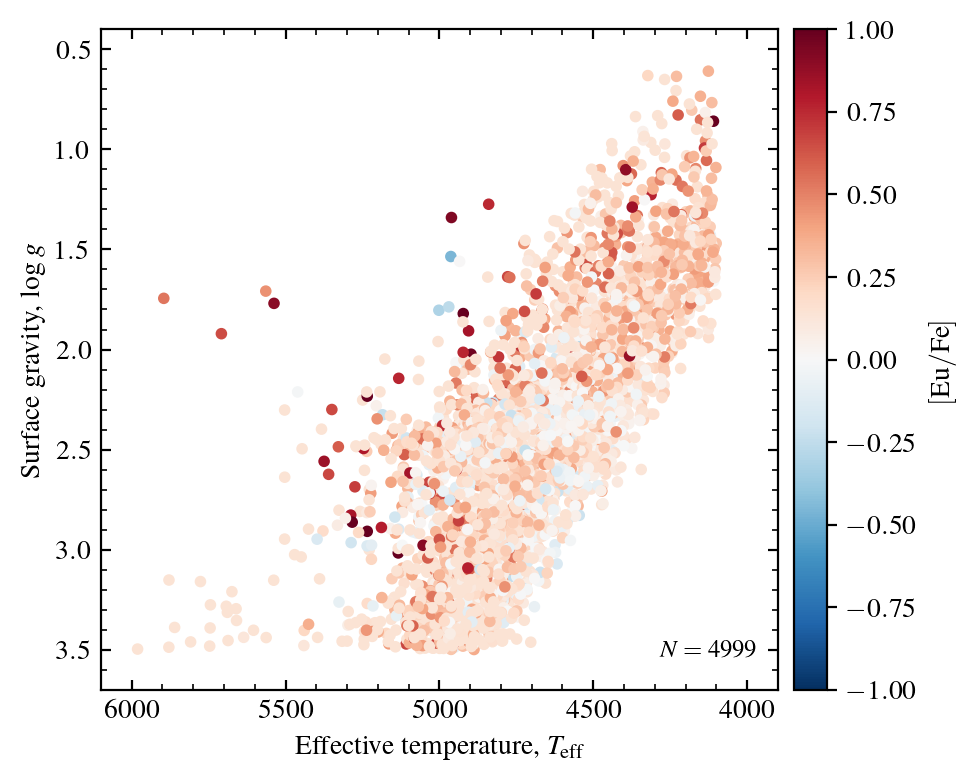

4999


In [ ]:
#Kiel representation of the GALAH DR3 cross matched sample with APOGEE

import matplotlib.pyplot as plt
import matplotlib as mpl




labels_full = np.array(label_data_h["labels"])   # (N_stars, n_labels)
names_full  = label_data_h["label_names"]

i_teff = names_full.index("teff")
i_logg = names_full.index("logg")
i_eu   = names_full.index("Eu_h")   # this is [Eu/H] after Cell 3 conversion
i_feh  = names_full.index("fe_h")

teff_all = labels_full[:, i_teff]
logg_all = labels_full[:, i_logg]
eu_fe_all = labels_full[:, i_eu] - labels_full[:, i_feh]  # back to [Eu/Fe]

# mask out missing Eu values (GALAH flags missing labels with large fill values)
valid = np.abs(eu_fe_all) < 3

fig, ax = plt.subplots(figsize=(5, 4), dpi=200)
sc = ax.scatter(teff_all[valid], logg_all[valid],
                c=eu_fe_all[valid], s=10, cmap='RdBu_r',
                vmin=-1, vmax=1, rasterized=True)

ax.set_xlim(6100, 3900)
ax.set_ylim(3.7, 0.4)
ax.set_xlabel(r'Effective temperature, $T_{\rm eff}$')
ax.set_ylabel(r'Surface gravity, $\log\,g$')
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r'$[{\rm Eu/Fe}]$')

N = valid.sum()
ax.text(0.97, 0.04, f'$N = {N}$', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9)

fig.tight_layout()
fig.savefig('/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/PaperFigures_Eu/kiel_diagram_data_section.pdf', bbox_inches='tight')
plt.show()
print(N)

In [6]:
n = 4000

train_ID = label_data_h['ids'][:n]
train_flux = spectra_data['fluxes'][:n]
train_flux_err = spectra_data['fluxes_err'][:n]
train_flux_ivar = spectra_data['fluxes_ivars'][:n]
train_label = label_data_h['labels'][:n]
train_label_err = label_data_h['labels_err'][:n]
train_label_ivar = label_data_h['labels_ivars'][:n]

test_ID = label_data_h['ids'][n:]
test_flux = spectra_data['fluxes'][n:]
test_flux_err = spectra_data['fluxes_err'][n:]
test_flux_ivar = spectra_data['fluxes_ivars'][n:]
test_label = label_data_h['labels'][n:]
test_label_err = label_data_h['labels_err'][n:]
test_label_ivar = label_data_h['labels_ivars'][n:]

In [7]:
l2reg = 1000
latent_dim = 'P49'
savepath = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Trainh/'
name = '_'+str(latent_dim)+'_L2regstrength'+str(l2reg)+'_omega1-train-giantsgalah'
alphas = np.load(savepath+'alphas_giants-withscatters'+str(name)+'.npy', allow_pickle=True)
betas = np.load(savepath+'betas_giants-withscatters'+str(name)+'.npy', allow_pickle=True)
zetas = np.load(savepath+'zetas_train_giants-withscatters'+str(name)+'.npy', allow_pickle=True)
ln_noise_fluxes_updated = jnp.log(np.load(savepath+'noise_fluxes_train_giants-withscatters'+str(name)+'.npy', allow_pickle=True))


# compute the new zetas

In [8]:
# first using the fluxes
P = 49
alphas_init_test, betas_init_test, zetas_init_test = il.initialise_alphas_betas_zetas(test_label, test_flux, P)

In [9]:
res_zetas_fromfluxes = opt_sc.get_zetas_test_using_fluxes(test_flux, test_flux_ivar, betas, zetas_init_test, ln_noise_fluxes_updated)
zetas_test_fromfluxes = res_zetas_fromfluxes.params['zetas']

In [10]:
labels_test_fromflux = zetas_test_fromfluxes @ alphas.T
spectra_test_fromflux = zetas_test_fromfluxes @ betas.T

In [11]:
savepath = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Trainh/'
name = '_49_L2regstrength1000_omega1-train-giantsgalah'
np.save(savepath+'zetas_test_fromflux_giants-withscatters'+str(name), zetas_test_fromfluxes)
np.save(savepath+'labels_test_fromflux_giants-withscatters'+str(name), labels_test_fromflux)
np.save(savepath+'spectra_test_fromflux_giants-withscatters'+str(name), spectra_test_fromflux)


In [12]:
savepath = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Trainh/'
name = '_49_L2regstrength1000_omega1-train-giantsgalah'
zetas_test_fromfluxes = np.load(savepath+'zetas_test_fromflux_giants-withscatters'+str(name)+'.npy', allow_pickle=True)
labels_test_fromflux = np.load(savepath+'labels_test_fromflux_giants-withscatters'+str(name)+'.npy', allow_pickle=True)
spectra_test_fromflux = np.load(savepath+'spectra_test_fromflux_giants-withscatters'+str(name)+'.npy', allow_pickle=True)

In [13]:
test_snr = label_data['snr'][4000:]

In [35]:
n = 10000
fig = plt.figure(figsize=(12, 10), constrained_layout=True)


plt.subplot(2,2,1)
plt.title('$T_{\\mathrm{eff}}$', fontsize=25)
plt.plot([3500,5500], [3500,5500], color='k', alpha=0.6, lw=2, ls='dashed')
color = plt.scatter(test_label[:n,0], labels_test_fromflux[:,0], c=test_snr, s=10, vmin=20, vmax=300, cmap=cm.torch)
plt.text(4500,3900, 'RMSE: '+str("{:.3f}".format(jnp.sqrt(1./len(test_label)*(jnp.nansum((test_label[:n,0]-labels_test_fromflux[:,0])**2))))), fontsize=20)
plt.text(4500,4050, 'Bias: '+str("{:.3f}".format(jnp.median(test_label[:n,0]-labels_test_fromflux[:,0]))), fontsize=20)
plt.text(4500,4200, 'Mean $\\sigma_{GALAH}$: '+str("{:.2f}".format(jnp.mean(test_label_err[:n,0]))), fontsize=20)
plt.xlim(3800,5300)
plt.ylim(3800,5300)
plt.ylabel(r'$Lux$', fontsize=25)
plt.tick_params(which='major', labelsize=12, direction='in', top=True, right=True, length=6)
plt.tick_params(which='minor', length=3, direction='in', top=True, right=True)
plt.minorticks_on()

plt.subplot(2,2,2)
plt.title('$\\log~g$', fontsize=25)
plt.plot([0,4],[0,4], color='k', alpha=0.6, lw=2, ls='dashed')
plt.text(2.5,0.7, 'RMSE: '+str("{:.3f}".format(jnp.sqrt(1./len(test_label)*(jnp.nansum((test_label[:n,1]-labels_test_fromflux[:,1])**2))))), fontsize=20)
plt.text(2.5,1.0, 'Bias: '+str("{:.3f}".format(jnp.mean(test_label[:n,1]-labels_test_fromflux[:,1]))), fontsize=20)
plt.text(2.5,1.3, 'Mean $\\sigma_{GALAH}$: '+str("{:.2f}".format(jnp.mean(test_label_err[:n,1]))), fontsize=20)
plt.scatter(test_label[:n,1], labels_test_fromflux[:,1], c=test_snr, s=10, vmin=20, vmax=300, cmap=cm.torch)
plt.xlim(0.5,4)
plt.ylim(0.5,4)
plt.tick_params(which='major', labelsize=12, direction='in', top=True, right=True, length=6)
plt.tick_params(which='minor', length=3, direction='in', top=True, right=True)
plt.minorticks_on()

plt.subplot(2,2,3)
plt.title('[Fe/H]', fontsize=25)
plt.plot([-2,0.5], [-2,0.5], color='k', alpha=0.6, lw=2, ls='dashed')
plt.text(-0.6,-1.5, 'RMSE: '+str("{:.3f}".format(jnp.sqrt(1./len(test_label)*(jnp.nansum((test_label[:n,2]-labels_test_fromflux[:,2])**2))))), fontsize=20)
plt.text(-0.6,-1.3, 'Bias: '+str("{:.3f}".format(jnp.mean(test_label[:n,2]-labels_test_fromflux[:,2]))), fontsize=20)
plt.text(-0.6,-1.1, 'Mean $\\sigma_{GALAH}$: '+str("{:.2f}".format(jnp.mean(test_label_err[:n,2]))), fontsize=20)
plt.scatter(test_label[:n,2], labels_test_fromflux[:,2], c=test_snr, s=10, vmin=20, vmax=300, cmap=cm.torch)
plt.xlim(-1.7,0.5)
plt.ylim(-1.7,0.5)
plt.ylabel(r'$Lux$', fontsize=25)
plt.xlabel(r'$GALAH$', fontsize=25)
plt.tick_params(which='major', labelsize=12, direction='in', top=True, right=True, length=6)
plt.tick_params(which='minor', length=3, direction='in', top=True, right=True)
plt.minorticks_on()

plt.subplot(2,2,4)
plt.title('[Eu/H]', fontsize=25)
mask = (np.abs(labels_test_fromflux[:,10])<1) & (np.abs(test_label[:,10])<1) \
     & ((test_label[:,10]>0.144312554)|(test_label[:,10]<0.144312552)) \
     & (np.abs(test_label_err[:n,10])<1)
plt.plot([-1,0.5], [-1,0.5], color='k', alpha=0.6, lw=2, ls='dashed')
plt.text(-0.1,-0.9, 'RMSE: '+str("{:.3f}".format(jnp.sqrt(1./len(test_label[mask])*(jnp.nansum((test_label[:n,10][mask]-labels_test_fromflux[:,10][mask])**2))))), fontsize=20)
plt.text(-0.1,-0.75, 'Bias: '+str("{:.3f}".format(jnp.mean(test_label[:n,10][mask]-labels_test_fromflux[:,10][mask]))), fontsize=20)
plt.text(-0.1,-0.6, 'Mean $\\sigma_{GALAH}$: '+str("{:.2f}".format(jnp.mean(test_label_err[:n,10][mask]))), fontsize=20)
plt.scatter(test_label[:n,10][mask], labels_test_fromflux[:,10][mask], c=test_snr[mask], s=10, vmin=20, vmax=300, cmap=cm.torch)
plt.xlim(-1,0.5)
plt.ylim(-1,0.5)
plt.xlabel(r'$GALAH$', fontsize=25)
plt.tick_params(which='major', labelsize=12, direction='in', top=True, right=True, length=6)
plt.tick_params(which='minor', length=3, direction='in', top=True, right=True)
plt.minorticks_on()

cbar_ax = fig.add_axes([0.25, 1.02, 0.5, 0.03])
cb = plt.colorbar(color, cax=cbar_ax, orientation='horizontal')
cb.set_label(label=r'Signal-to-noise', fontsize=25, labelpad=10)
cb.ax.tick_params(labelsize=14)
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')

plt.savefig('/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/CV-test-galahstarshydrogen-lux.pdf',
            dpi=200, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2561094/1542923699.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [1]:
fig = plt.figure(figsize=(30, 10), facecolor='white')
fig.suptitle('$GALAH$ abundances for $APOGEE$ giants',fontsize=50,x=0.51,y=1.05)

plt.subplot(2,6,1)
plt.title('[Li/Fe]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,3], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.ylabel('$Lux$', fontsize=30)
plt.xlim(-2,0.5)
plt.ylim(-2,3)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,2)
plt.title('[Na/Fe]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,4], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-0.3,0.6)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,3)
plt.title('[Y/Fe]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,7], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,4)
plt.title('[Ce/Fe]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,8], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,5)
plt.title('[Ba/Fe]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,9], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,6)
plt.title('[Eu/Fe]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,10], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-0.5,1)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()


plt.subplot(2,6,7)
# plt.title('[Li/Fe]', fontsize=25)
plt.ylabel('$GALAH$', fontsize=30)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.xlim(-2,0.5)
plt.ylim(-2,3)
plt.scatter(test_label[:,2], test_label[:,3], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,8)
# plt.title('[Na/Fe]', fontsize=25)
plt.scatter(test_label[:,2], test_label[:,4], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-0.3,0.6)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,9)
# plt.title('[Y/Fe]', fontsize=25)
plt.scatter(test_label[:,2], test_label[:,7], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,10)
# plt.title('[Ce/Fe]', fontsize=25)
plt.scatter(test_label[:,2], test_label[:,8], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,11)
# plt.title('[Ba/Fe]', fontsize=25)
plt.scatter(test_label[:,2], test_label[:,9], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,12)
# plt.title('[Eu/Fe]', fontsize=25)
plt.scatter(test_label[:,2], test_label[:,10], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-0.5,1)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.savefig('/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/abundances-galahstars-Luxhydrogen.pdf',dpi=200, bbox_inches = 'tight')

NameError: name 'plt' is not defined

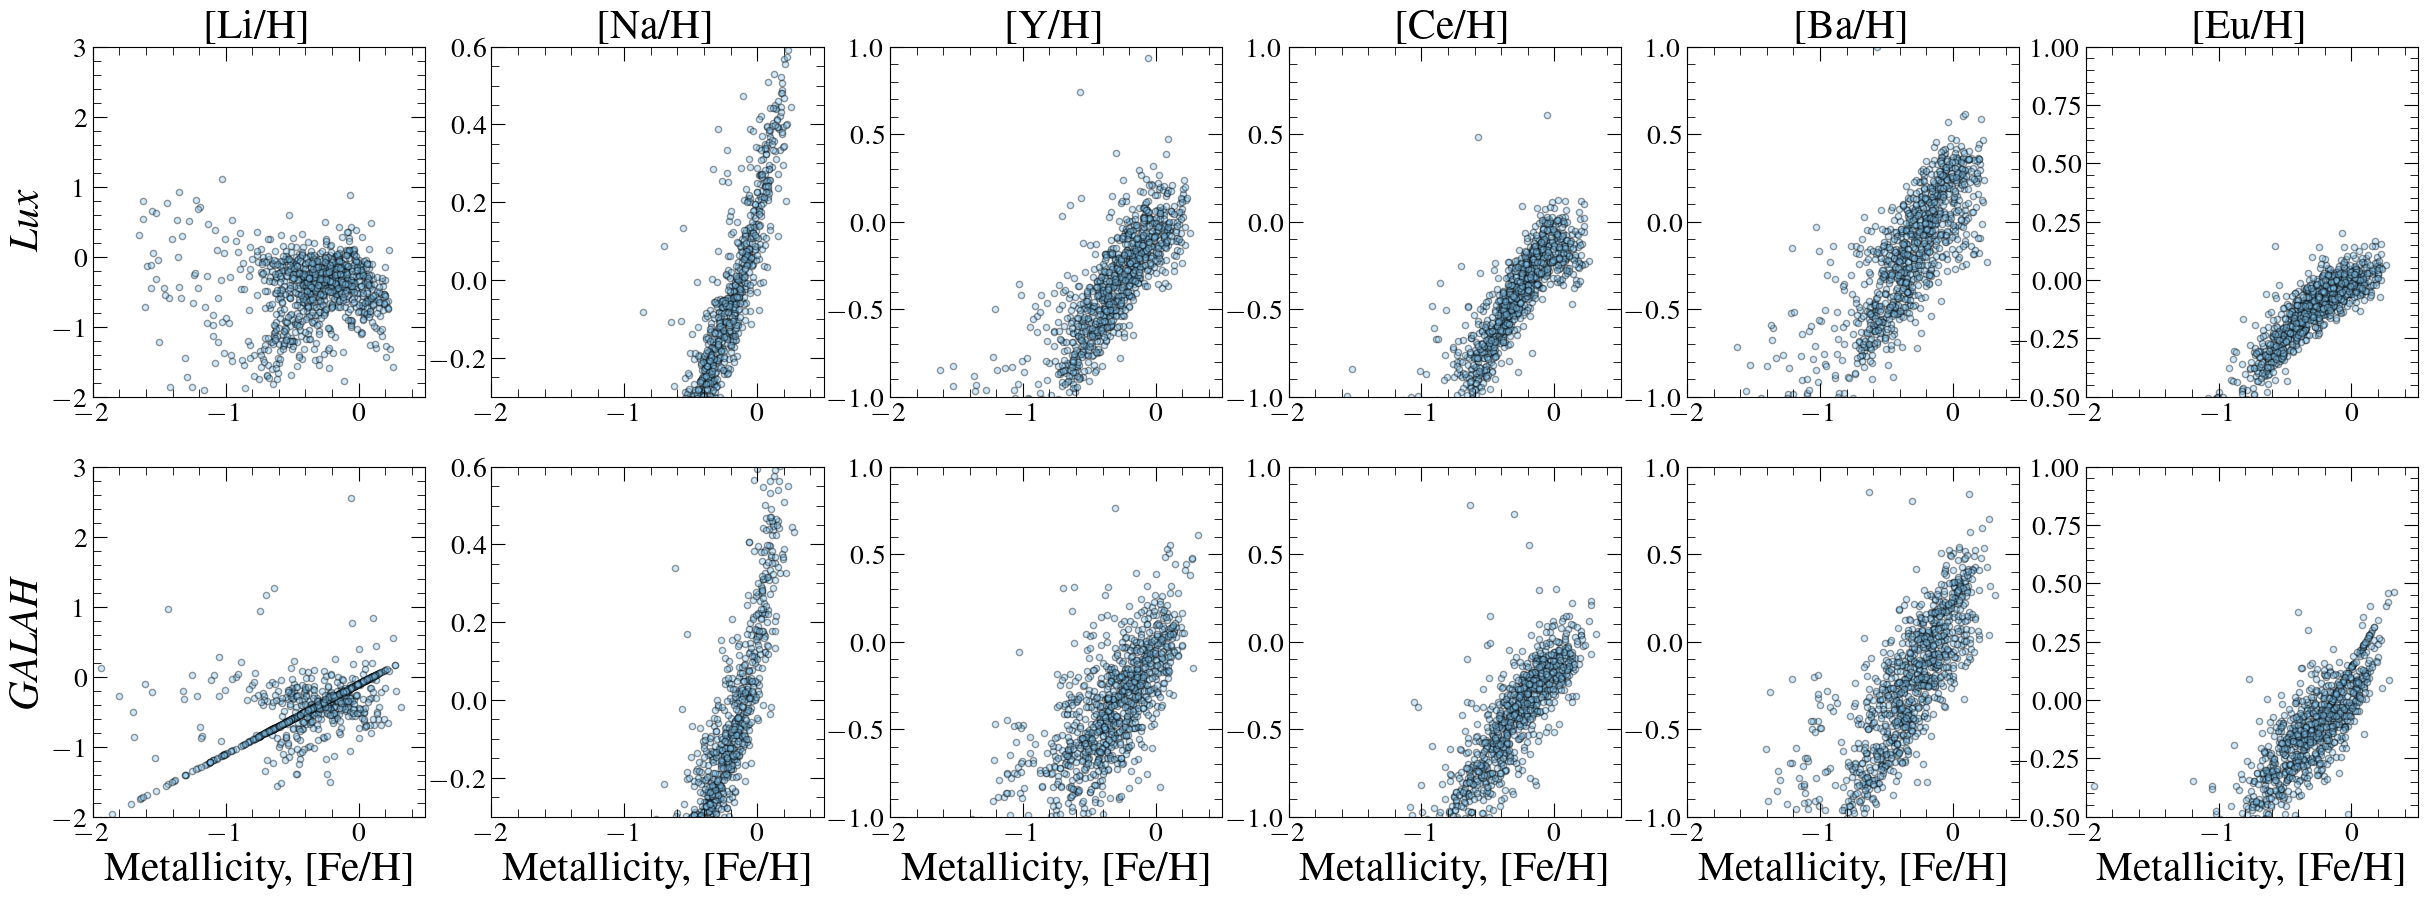

In [ ]:
##Updated to be normalised to hydrogen

fig = plt.figure(figsize=(30, 10), facecolor='white')
# fig.suptitle('$GALAH$ abundances for $APOGEE$ giants',fontsize=50,x=0.51,y=1.05)

plt.subplot(2,6,1)
plt.title('[Li/H]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,3], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.ylabel('$Lux$', fontsize=30)
plt.xlim(-2,0.5)
plt.ylim(-2,3)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,2)
plt.title('[Na/H]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,4], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-0.3,0.6)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,3)
plt.title('[Y/H]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,7], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,4)
plt.title('[Ce/H]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,8], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,5)
plt.title('[Ba/H]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,9], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,6)
plt.title('[Eu/H]', fontsize=30)
plt.scatter(labels_test_fromflux[:,2], labels_test_fromflux[:,10], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-0.5,1)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()


plt.subplot(2,6,7)
# plt.title('[Li/Fe]', fontsize=25)
plt.ylabel('$GALAH$', fontsize=30)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.xlim(-2,0.5)
plt.ylim(-2,3)
plt.scatter(test_label[:,2], test_label[:,3], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,8)
# plt.title('[Na/Fe]', fontsize=25)
plt.scatter(test_label[:,2], test_label[:,4], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-0.3,0.6)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,9)
# plt.title('[Y/Fe]', fontsize=25)
plt.scatter(test_label[:,2], test_label[:,7], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,10)
# plt.title('[Ce/Fe]', fontsize=25)
plt.scatter(test_label[:,2], test_label[:,8], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.subplot(2,6,11)
# plt.title('[Ba/Fe]', fontsize=25)
plt.scatter(test_label[:,2], test_label[:,9], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-1,1)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

python# Your pairs variable already has the indices - e.g. for statistical pair 1
# the stars are at indices 452 and 222 in your test set

# Get the 2MASS ID or APOGEE ID for each star
star_idx_1 = 452
star_idx_2 = 222

# Assuming your test set dataframe is called something like test_data or X_test
# and has a column for IDs - check what columns you have
print(test_data.columns)  # or whatever your dataframe is called

# Likely column names to look for:
# '2MASS_ID', 'APOGEE_ID', 'sobject_id' (GALAH), 'tmass_id'
apogee_id_1 = test_data['APOGEE_ID'].iloc[star_idx_1]
apogee_id_2 = test_data['APOGEE_ID'].iloc[star_idx_2]

plt.subplot(2,6,12)
# plt.title('[Eu/Fe]', fontsize=25)
plt.scatter(test_label[:,2], test_label[:,10], s=20, c='lightskyblue', alpha=0.4, edgecolors='k')
plt.xlim(-2,0.5)
plt.ylim(-0.5,1)
plt.xlabel('Metallicity, [Fe/H]', fontsize=30)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.savefig('/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/abundances-galahstars-Luxhydrogen.pdf',dpi=200, bbox_inches = 'tight')

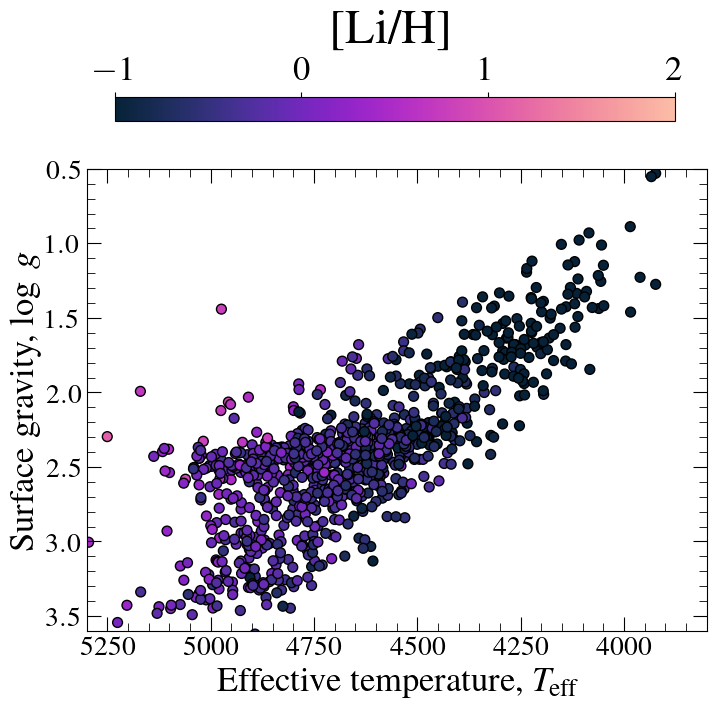

In [16]:
fig = plt.figure(figsize=(8,6), facecolor='white')

color = plt.scatter(labels_test_fromflux[:,0], labels_test_fromflux[:,1], c=labels_test_fromflux[:,3], s=50, cmap=cm.bubblegum, edgecolors='k', vmin=-1, vmax=2)
plt.xlim(5300,3800)
plt.ylim(3.6, 0.5)
# plt.colorbar(label='[Li/Fe]')
plt.xlabel('Effective temperature, $T_{\mathrm{eff}}$', fontsize=25)
plt.ylabel('Surface gravity, $\log~g$', fontsize=25)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

cbar_ax = fig.add_axes([0.16, 0.96, 0.7,0.04])
cb = plt.colorbar(cax = cbar_ax,orientation='horizontal')
cb.set_label(label=r'[Li/H]',fontsize=35,labelpad=10)
cb.ax.tick_params(labelsize=25)
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')

{'wl': Array([15100.80154164, 15101.01016837, 15101.21879797, ...,
       16999.33764336, 16999.57249951, 16999.80735891], dtype=float64), 'fluxes': Array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float64), 'fluxes_err': Array([[9999., 9999., 9999., ..., 9999., 9999., 9999.],
       [9999., 9999., 9999., ..., 9999., 9999., 9999.],
       [9999., 9999., 9999., ..., 9999., 9999., 9999.],
       ...,
       [9999., 9999., 9999., ..., 9999., 9999., 9999.],
       [9999., 9999., 9999., ..., 9999., 9999., 9999.],
       [9999., 9999., 9999., ..., 9999., 9999., 9999.]], dtype=float64), 'fluxes_ivars': Array([[0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
       [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
       [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
       ...,
       [0.01, 0.01, 0.01, ..., 0.01, 

In [ ]:
#Seperates each abundance and corresponding errors out

labels_full = label_data_h["labels"]
names = label_data_h["label_names"]
labels_err_full = label_data_h["labels_err"]
err_names = label_data_h["label_names_err"]


test_ind = 4000
labels = np.array(labels_full[test_ind:]) 
labels_err = np.array(labels_err_full[test_ind:])


i_teff = names.index("teff")
teff = labels[:, i_teff]
i_logg = names.index("logg")
logg = labels[:, i_logg]
i_fe_h = names.index("fe_h")
Fe_h = labels[:, i_fe_h]

i_Li_h = names.index("Li_h")
Li_h = labels[:, i_Li_h]
i_Na_h = names.index("Na_h")
Na_h = labels[:, i_Na_h]
i_O_h  = names.index("O_h")
O_h  = labels[:, i_O_h]
i_Mg_h = names.index("Mg_h")
Mg_h = labels[:, i_Mg_h]
i_Y_h  = names.index("Y_h")
Y_h  = labels[:, i_Y_h]
i_Ce_h = names.index("Ce_h")
Ce_h = labels[:, i_Ce_h]
i_Ba_h = names.index("Ba_h")
Ba_h = labels[:, i_Ba_h]
i_Eu_h = names.index("Eu_h")
Eu_h = labels[:, i_Eu_h]

# --- errors ---
i_e_teff = err_names.index("e_teff")
teff_errors = labels_err[:, i_e_teff]
i_e_logg = err_names.index("e_logg")
logg_errors = labels_err[:, i_e_logg]
i_e_fe_h = err_names.index("e_fe_h")
fe_h_errors = labels_err[:, i_e_fe_h]

i_e_Li_h = err_names.index("e_Li_h")
Li_h_errors = labels_err[:, i_e_Li_h]
i_e_Na_h = err_names.index("e_Na_h")
Na_h_errors = labels_err[:, i_e_Na_h]
i_e_O_h  = err_names.index("e_O_h")
O_h_errors  = labels_err[:, i_e_O_h]
i_e_Mg_h = err_names.index("e_Mg_h")
Mg_h_errors = labels_err[:, i_e_Mg_h]
i_e_Y_h  = err_names.index("e_Y_h")
Y_h_errors  = labels_err[:, i_e_Y_h]
i_e_Ce_h = err_names.index("e_Ce_h")
Ce_h_errors = labels_err[:, i_e_Ce_h]
i_e_Ba_h = err_names.index("e_Ba_h")
Ba_h_errors = labels_err[:, i_e_Ba_h]
i_e_Eu_h = err_names.index("e_Eu_h")
Eu_h_errors = labels_err[:, i_e_Eu_h]

In [ ]:
# Determening nearest neighbours for stars - been replaced with a function method approach but good to keep as backup


# def error_satistical_model(k, error_reference, errors):
#     errors = np.maximum(errors, 1e-12)
#     error_reference = np.maximum(error_reference, 1e-12)
#     tol = k* np.sqrt(error_reference**2 + errors**2)
#     return tol

# k_same = 0.2
# k_diff = 4.0
# tol_teff = 20
# tol_logg = 0.1
# tol_abundancy = 0.058
# diff_abundancy = 0.2
# pairs = [] 

# """I've done this in two different ways. one sets arbritrary tollerance values, one says if the diference is less than the standard error on the difference to within 1 sigma then they are the same 
# """
# for i in range(len(teff)):
#     match = (np.abs(teff - teff[i]) <= tol_teff) \
#         & (np.abs(logg - logg[i]) <= tol_logg) \
#         & (np.abs(Fe_h  - Fe_h[i])  <= tol_abundancy) \
#         & (np.abs(Mg_h - Mg_h[i]) <= tol_abundancy) \
#         & (np.abs(Li_h  - Li_h[i])  <= diff_abundancy) \
#         & (np.abs(Na_h  - Na_h[i])  <= tol_abundancy) \
#         & (np.abs(O_h  - O_h[i])  <= tol_abundancy) \
#         & (np.abs(Y_h  - Y_h[i])  <= tol_abundancy) \
#         & (np.abs(Ce_h  - Ce_h[i])  <= tol_abundancy) \
#         & (np.abs(Ba_h  - Ba_h[i])  <= tol_abundancy) \
#         & (np.abs(Eu_h  - Eu_h[i])  >= tol_abundancy) \
        
# # for i in range(len(teff)):
# #     match = (
# #         (np.abs(teff - teff[i]) <= error_satistical_model(k_same, teff_errors[i], teff_errors)) &
# #         (np.abs(logg - logg[i]) <= error_satistical_model(k_same, logg_errors[i], logg_errors)) &
# #         (np.abs(Fe_h - Fe_h[i]) <= error_satistical_model(k_same, fe_h_errors[i], fe_h_errors)) &
# #         (np.abs(Mg_h - Mg_h[i]) <= error_satistical_model(k_same, Mg_h_errors[i], Mg_h_errors)) &
# #         # Li must be DIFFERENT (k_diff sigma away)
# #         (np.abs(Li_h - Li_h[i]) <= error_satistical_model(k_diff, Li_h_errors[i], Li_h_errors)) &
# #         (np.abs(Na_h - Na_h[i]) <= error_satistical_model(k_same, Na_h_errors[i], Na_h_errors)) &
# #         (np.abs(O_h  - O_h[i])  <= error_satistical_model(k_same, O_h_errors[i],  O_h_errors))  &
# #         (np.abs(Y_h  - Y_h[i])  <= error_satistical_model(k_same, Y_h_errors[i],  Y_h_errors))  &
# #         (np.abs(Ce_h - Ce_h[i]) <= error_satistical_model(k_same, Ce_h_errors[i], Ce_h_errors)) &
# #         (np.abs(Ba_h - Ba_h[i]) <= error_satistical_model(k_same, Ba_h_errors[i], Ba_h_errors)) &
# #         (np.abs(Eu_h - Eu_h[i]) >= error_satistical_model(k_same, Eu_h_errors[i], Eu_h_errors))
# #   )
       
#     match[i] = False  # exclude itself
#     js = np.where(match)[0] #where returns a tupple, this looks like [[True, False, False, True, False]], returns indices where True, i.e the above condition is met

#     for j in js:
#         if i < j: #exlude smaller as double count
#             pairs.append((i, j))

# print(pairs)


# print(labels[(pairs)])


# i,j = pairs[0]
# Ei = Eu_h[i]
# Ej = Eu_h[j]

# less_val = np.minimum(Ei, Ej)
# more_val = np.maximum(Ei, Ej)

# # which index is which?
# less_idx = i if Ei <= Ej else j
# more_idx = j if Ei <= Ej else i

# less_label = f"less abundant ({less_val:+.3f} dex)"
# more_label = f"more abundant ({more_val:+.3f} dex)"

# print(more_label)
# print(less_label)
# more_spec = spectra_test_fromflux[more_idx]
# less_spec = spectra_test_fromflux[less_idx]
# wavelengths = spectra_data["wl"]

# diff_spectra = more_spec - less_spec

# # plt.plot(wavelengths, spec_i)
# # plt.show()
# # plt.plot(wavelengths, spec_j)
# # plt.show()
# plt.plot(wavelengths, diff_spectra)

In [ ]:

# CONFIG — edit here to switch between Li / Eu analysis


# Element whose abundance must DIFFER between doppelganger pairs
# Options: 'Li_h', 'Eu_h', 'Na_h', 'Ba_h' etc.
FILTER_METHOD  = 'statistical'        # 'fixed' or 'statistical'

DIFF_ELEMENT   = 'Eu_h'

# Label to compute derivatives for (should match DIFF_ELEMENT)
DERIV_LABEL    = 'Eu_h'

# Spectral regions of interest to highlight (lower, upper, alpha)
# Li regions
REGIONS_LI = [
    (16340, 16355, 0.25),
    (16902, 16910, 0.25),
]
# Eu regions
REGIONS_EU = [
    (16035, 16038, 0.25),
    (16137, 16143, 0.25),
    (16235, 16239, 0.20),
    (16355, 16360, 0.25),
]
REGIONS = REGIONS_EU   # <-- change to REGIONS_EU when analysing Eu

# Zoom window for detailed spectral plots
ZOOM_XMIN = 16850   # <-- change to zoom into different wavelength regions
ZOOM_XMAX = 16950

# Output directories
BASE_PLOT_DIR = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/'
# ============================================================

# )

# ── Doppelganger selection tolerances ─────────────────────────────────────────
k_same             = 1.0    # Max abundance difference for "same" labels
k_diff             = 2.0   # Min sigma separation for the target (differing) element
tol_teff           = 20     # Teff tolerance (K)
tol_logg           = 0.1    # log g tolerance (dex)  # Tolerance for all non-target abundances (dex)
tol_abundancy_Li   = 0.076  # Tolerance for non-target Li abundance (dex)
tol_abundancy_Eu   = 0.076  # Tolerance for non-target Eu abundance (dex)
diff_abundancy     = 0.2    # Minimum difference required in target element (dex)
# ──────────────────────────────────────────────────────────────────────────────

In [16]:

def error_satistical_model(k, error_reference, errors):
    errors = np.maximum(errors, 1e-12)
    error_reference = np.maximum(error_reference, 1e-12)
    tol = k* np.sqrt(error_reference**2 + errors**2)
    return tol


In [ ]:
#function that carries out the filter logic and returns a list of the matches found
def find_doppelganger_pairs(method, diff_element):
    """
    method='fixed'       : hard-coded tolerances, exact copy of original working filter
    method='statistical' : per-star error-based tolerances (k_same / k_diff sigma)
    diff_element         : 'Li_h' or 'Eu_h' — the element that must DIFFER
    """


    labels_full = label_data_h["labels"]
    names = label_data_h["label_names"]
    labels_err_full = label_data_h["labels_err"]
    err_names = label_data_h["label_names_err"]


    test_ind = 4000
    labels = np.array(labels_full[test_ind:]) 
    labels_err = np.array(labels_err_full[test_ind:])


    # --- values ---
    i_teff = names.index("teff")
    teff = labels[:, i_teff]
    i_logg = names.index("logg")
    logg = labels[:, i_logg]
    i_fe_h = names.index("fe_h")
    Fe_h = labels[:, i_fe_h]

    i_Li_h = names.index("Li_h")
    Li_h = labels[:, i_Li_h]
    i_Na_h = names.index("Na_h")
    Na_h = labels[:, i_Na_h]
    i_O_h  = names.index("O_h")
    O_h  = labels[:, i_O_h]
    i_Mg_h = names.index("Mg_h")
    Mg_h = labels[:, i_Mg_h]
    i_Y_h  = names.index("Y_h")
    Y_h  = labels[:, i_Y_h]
    i_Ce_h = names.index("Ce_h")
    Ce_h = labels[:, i_Ce_h]
    i_Ba_h = names.index("Ba_h")
    Ba_h = labels[:, i_Ba_h]
    i_Eu_h = names.index("Eu_h")
    Eu_h = labels[:, i_Eu_h]

    # --- errors ---
    i_e_teff = err_names.index("e_teff")
    teff_errors = labels_err[:, i_e_teff]
    i_e_logg = err_names.index("e_logg")
    logg_errors = labels_err[:, i_e_logg]
    i_e_fe_h = err_names.index("e_fe_h")
    fe_h_errors = labels_err[:, i_e_fe_h]

    i_e_Li_h = err_names.index("e_Li_h")
    Li_h_errors = labels_err[:, i_e_Li_h]
    i_e_Na_h = err_names.index("e_Na_h")
    Na_h_errors = labels_err[:, i_e_Na_h]
    i_e_O_h  = err_names.index("e_O_h")
    O_h_errors  = labels_err[:, i_e_O_h]
    i_e_Mg_h = err_names.index("e_Mg_h")
    Mg_h_errors = labels_err[:, i_e_Mg_h]
    i_e_Y_h  = err_names.index("e_Y_h")
    Y_h_errors  = labels_err[:, i_e_Y_h]
    i_e_Ce_h = err_names.index("e_Ce_h")
    Ce_h_errors = labels_err[:, i_e_Ce_h]
    i_e_Ba_h = err_names.index("e_Ba_h")
    Ba_h_errors = labels_err[:, i_e_Ba_h]
    i_e_Eu_h = err_names.index("e_Eu_h")
    Eu_h_errors = labels_err[:, i_e_Eu_h]
    pairs = []

    if method == 'fixed':
        for i in range(len(teff)):
            if diff_element == 'Li_h':
                match = (np.abs(teff - teff[i]) <= tol_teff) \
                    & (np.abs(logg - logg[i]) <= tol_logg) \
                    & (np.abs(Fe_h  - Fe_h[i])  <= tol_abundancy_Li) \
                    & (np.abs(Mg_h - Mg_h[i]) <= tol_abundancy_Li) \
                    & (np.abs(Li_h  - Li_h[i])  >= diff_abundancy_Li) \
                    & (np.abs(Na_h  - Na_h[i])  <= tol_abundancy_Li) \
                    & (np.abs(O_h   - O_h[i])   <= tol_abundancy_Li) \
                    & (np.abs(Y_h   - Y_h[i])   <= tol_abundancy_Li) \
                    & (np.abs(Ce_h  - Ce_h[i])  <= tol_abundancy_Li) \
                    & (np.abs(Ba_h  - Ba_h[i])  <= tol_abundancy_Li) \
                    & (np.abs(Eu_h  - Eu_h[i])  <= tol_abundancy_Li)
            elif diff_element == 'Eu_h':
                match = (np.abs(teff - teff[i]) <= tol_teff) \
                    & (np.abs(logg - logg[i]) <= tol_logg) \
                    & (np.abs(Fe_h  - Fe_h[i])  <= tol_abundancy_Eu) \
                    & (np.abs(Mg_h - Mg_h[i]) <= tol_abundancy_Eu) \
                    & (np.abs(Li_h  - Li_h[i])  <= tol_abundancy_Eu) \
                    & (np.abs(Na_h  - Na_h[i])  <= tol_abundancy_Eu) \
                    & (np.abs(O_h   - O_h[i])   <= tol_abundancy_Eu) \
                    & (np.abs(Y_h   - Y_h[i])   <= tol_abundancy_Eu) \
                    & (np.abs(Ce_h  - Ce_h[i])  <= tol_abundancy_Eu) \
                    & (np.abs(Ba_h  - Ba_h[i])  <= tol_abundancy_Eu) \
                    & (np.abs(Eu_h  - Eu_h[i])  >= diff_abundancy)
            else:
                raise ValueError(f"diff_element '{diff_element}' not supported for fixed method")

            match[i] = False  # exclude itself
            js = np.where(match)[0]
            for j in js:
                if i < j:  # exclude double count
                    pairs.append((i, j))

    elif method == 'statistical':
        
        for i in range(len(teff)):
            if diff_element == 'Li_h':
                match = (
                    (np.abs(teff - teff[i]) <= error_satistical_model(k_same, teff_errors[i], teff_errors)) &
                    (np.abs(logg - logg[i]) <= error_satistical_model(k_same, logg_errors[i], logg_errors)) &
                    (np.abs(Fe_h - Fe_h[i]) <= error_satistical_model(k_same, fe_h_errors[i], fe_h_errors)) &
                    (np.abs(Mg_h - Mg_h[i]) <= error_satistical_model(k_same, Mg_h_errors[i], Mg_h_errors)) &
                    (np.abs(Li_h - Li_h[i]) >= error_satistical_model(k_diff, Li_h_errors[i], Li_h_errors)) &
                    (np.abs(Na_h - Na_h[i]) <= error_satistical_model(k_same, Na_h_errors[i], Na_h_errors)) &
                    (np.abs(O_h  - O_h[i])  <= error_satistical_model(k_same, O_h_errors[i],  O_h_errors))  &
                    (np.abs(Y_h  - Y_h[i])  <= error_satistical_model(k_same, Y_h_errors[i],  Y_h_errors))  &
                    (np.abs(Ce_h - Ce_h[i]) <= error_satistical_model(k_same, Ce_h_errors[i], Ce_h_errors)) &
                    (np.abs(Ba_h - Ba_h[i]) <= error_satistical_model(k_same, Ba_h_errors[i], Ba_h_errors)) &
                    (np.abs(Eu_h - Eu_h[i]) <= error_satistical_model(k_same, Eu_h_errors[i], Eu_h_errors))
                )
            elif diff_element == 'Eu_h':
                match = (
                    (np.abs(teff - teff[i]) <= error_satistical_model(k_same, teff_errors[i], teff_errors)) &
                    (np.abs(logg - logg[i]) <= error_satistical_model(k_same, logg_errors[i], logg_errors)) &
                    (np.abs(Fe_h - Fe_h[i]) <= error_satistical_model(k_same, fe_h_errors[i], fe_h_errors)) &
                    (np.abs(Mg_h - Mg_h[i]) <= error_satistical_model(k_same, Mg_h_errors[i], Mg_h_errors)) &
                    (np.abs(Li_h - Li_h[i]) <= error_satistical_model(k_same, Li_h_errors[i], Li_h_errors)) &
                    (np.abs(Na_h - Na_h[i]) <= error_satistical_model(k_same, Na_h_errors[i], Na_h_errors)) &
                    (np.abs(O_h  - O_h[i])  <= error_satistical_model(k_same, O_h_errors[i],  O_h_errors))  &
                    (np.abs(Y_h  - Y_h[i])  <= error_satistical_model(k_same, Y_h_errors[i],  Y_h_errors))  &
                    (np.abs(Ce_h - Ce_h[i]) <= error_satistical_model(k_same, Ce_h_errors[i], Ce_h_errors)) &
                    (np.abs(Ba_h - Ba_h[i]) <= error_satistical_model(k_same, Ba_h_errors[i], Ba_h_errors)) &
                    (np.abs(Eu_h - Eu_h[i]) >= error_satistical_model(k_diff, Eu_h_errors[i], Eu_h_errors))
                )
            else:
                raise ValueError(f"diff_element '{diff_element}' not supported for statistical method")

            match[i] = False  # exclude itself
            js = np.where(match)[0]
            for j in js:
                if i < j:  # exclude double count
                    pairs.append((i, j))

    else:
        raise ValueError(f"method must be 'fixed' or 'statistical', got '{method}'")

    return pairs


# %% Run the filter
pairs = find_doppelganger_pairs(method=FILTER_METHOD, diff_element=DIFF_ELEMENT)
print(f'Found {len(pairs)} doppelganger pairs (method={FILTER_METHOD}, diff_element={DIFF_ELEMENT})')
print(pairs)
# print(labels[pairs])


# %% Inspect a doppelganger pair
# ── Set PAIR_IDX to inspect a specific pair, or set to None to loop all pairs ─
PAIR_IDX = 1  # <-- change this, or set to None to print all pairs
# ──────────────────────────────────────────────────────────────────────────────

element_arrays_vals = {
    'Li_h': Li_h, 'Na_h': Na_h, 'O_h': O_h,  'Mg_h': Mg_h,
    'Y_h':  Y_h,  'Ce_h': Ce_h, 'Ba_h': Ba_h, 'Eu_h': Eu_h,
}
diff_arr = element_arrays_vals[DIFF_ELEMENT]

def inspect_pair(pair_idx):
    i, j = pairs[pair_idx]
    Ei = diff_arr[i]
    Ej = diff_arr[j]

    less_val = np.minimum(Ei, Ej)
    more_val = np.maximum(Ei, Ej)
    less_idx = i if Ei <= Ej else j
    more_idx = j if Ei <= Ej else i

    less_label = f"less abundant ({less_val:+.3f} dex)"
    more_label  = f"more abundant ({more_val:+.3f} dex)"

    more_spec    = spectra_test_fromflux[more_idx]
    less_spec    = spectra_test_fromflux[less_idx]
    wavelengths  = spectra_data["wl"]
    diff_spectra = more_spec - less_spec

    print(f'Pair {pair_idx}: star {i} vs star {j}')
    print(f'  {more_label}')
    print(f'  {less_label}')
    print(f'  Separation: {abs(more_val - less_val):.3f} dex')
    print(f' Logg: more {logg[more_idx]}, less {logg[less_idx]}' )
    print(f' Fe_h: more {Fe_h[more_idx]}, less {Fe_h[less_idx]}' )
    print(f' Fe_h: more {teff[more_idx]}, less {teff[less_idx]}' )
    print(f' Mg_h: more {Mg_h[more_idx]}, less {Mg_h[less_idx]}' )


    return more_spec, less_spec, diff_spectra, wavelengths, more_label, less_label, more_idx, less_idx

# Run for selected pair or all pairs
indices_to_plot = range(len(pairs)) if PAIR_IDX is None else [PAIR_IDX]

for idx in indices_to_plot:
    more_spec, less_spec, diff_spectra, wavelengths, more_label, less_label, more_idx, less_idx = inspect_pair(idx)


Found 3 doppelganger pairs (method=statistical, diff_element=Eu_h)
[(222, np.int64(452)), (394, np.int64(527)), (753, np.int64(844))]
Pair 1: star 394 vs star 527
  more abundant (+0.188 dex)
  less abundant (-0.025 dex)
  Separation: 0.213 dex
 Logg: more 2.597773313522339, less 2.3206093311309814
 Fe_h: more 0.011771202087402344, less -0.016019344329833984
 Fe_h: more 4465.7568359375, less 4571.21484375
 Mg_h: more 0.073132419586182, less -0.0057683944702144885


In [37]:
# Get the actual catalogue IDs for your doppelgänger pairs
# pairs contains your matched indices from find_doppelganger_pairs()

for i, (idx1, idx2) in enumerate(pairs):
    id1 = test_ID[idx1]
    id2 = test_ID[idx2]
    eu1 = test_label[idx1, names.index('Eu_h')]
    eu2 = test_label[idx2, names.index('Eu_h')]
    feh1 = test_label[idx1, names.index('fe_h')]
    feh2 = test_label[idx2, names.index('fe_h')]
    print(f"Pair {i+1}: Star {idx1} -> ID: {id1}, [Eu/H]={eu1:.3f}, [Fe/H]={feh1:.3f}")
    print(f"Pair {i+1}: Star {idx2} -> ID: {id2}, [Eu/H]={eu2:.3f}, [Fe/H]={feh2:.3f}")

fig, ax = plt.subplots(figsize=(8,6))

# your existing scatter
ax.scatter(test_label[:, names.index('fe_h')], 
           test_label[:, names.index('Eu_h')],
           s=10, alpha=0.4, c='grey')

# highlight doppelgänger pairs
colours = ['red', 'blue', 'green']
for i, (idx1, idx2) in enumerate(pairs):
    feh1 = test_label[idx1, names.index('fe_h')]
    eu1  = test_label[idx1, names.index('Eu_h')]
    feh2 = test_label[idx2, names.index('fe_h')]
    eu2  = test_label[idx2, names.index('Eu_h')]
    
    ax.scatter(feh1, eu1, s=150, facecolors='none',
               edgecolors=colours[i], linewidths=2, zorder=5,
               label=f'Pair {i+1} star A (idx {idx1})')
    ax.scatter(feh2, eu2, s=150, facecolors='none',
               edgecolors=colours[i], linewidths=2, 
               linestyles='dashed', zorder=5,
               label=f'Pair {i+1} star B (idx {idx2})')

ax.legend()
ax.set_xlabel('[Fe/H]', fontsize=16)
ax.set_ylabel('[Eu/H]', fontsize=16)
plt.savefig('/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/EuvsFe',
            dpi=200, bbox_inches='tight')
plt.show()

Pair 1: Star 222 -> ID: 2M14142034-4902256, [Eu/H]=-0.186, [Fe/H]=-0.057
Pair 1: Star 452 -> ID: 2M15595100-2012250, [Eu/H]=0.106, [Fe/H]=-0.028
Pair 2: Star 394 -> ID: 2M15584711-2316308, [Eu/H]=-0.025, [Fe/H]=-0.016
Pair 2: Star 527 -> ID: 2M16021266-1944047, [Eu/H]=0.188, [Fe/H]=0.012
Pair 3: Star 753 -> ID: 2M16131206-2254253, [Eu/H]=0.162, [Fe/H]=-0.093
Pair 3: Star 844 -> ID: 2M16234431-2551312, [Eu/H]=-0.160, [Fe/H]=-0.049


/tmp/ipykernel_2561094/3882405343.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Star A: idx 145, [Eu/H]=0.378, [Fe/H]=-0.403
Star B: idx 882, [Eu/H]=-0.510, [Fe/H]=-0.408
Eu separation: 0.887 dex


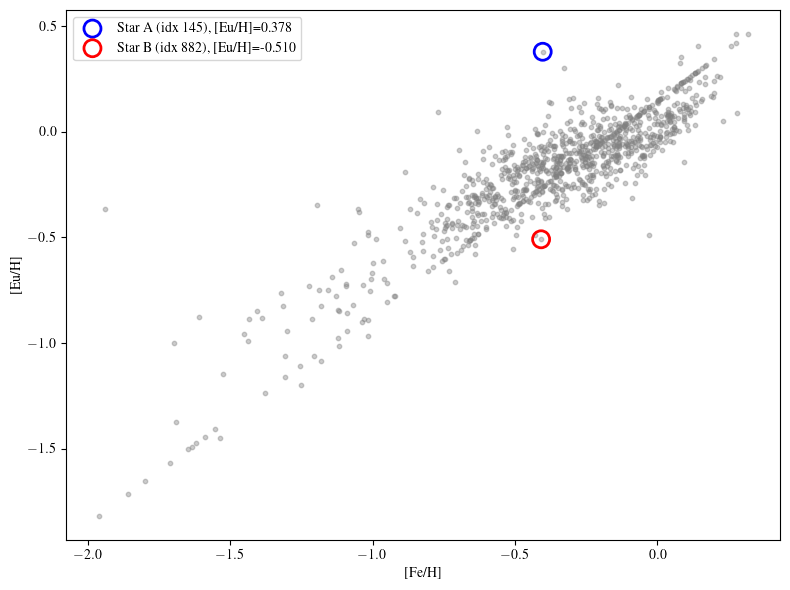

In [ ]:
#Eu/Fe plots

fig, ax = plt.subplots(figsize=(8,6))

# Background scatter of all test stars
ax.scatter(feh_all, eu_all, s=10, alpha=0.4, c='grey')

# Highlight the best pair
ax.scatter(feh_all[i], eu_all[i], s=150, facecolors='none',
           edgecolors='blue', linewidths=2, zorder=5,
           label=f'Star A (idx {i}), [Eu/H]={eu_all[i]:.3f}')
ax.scatter(feh_all[j], eu_all[j], s=150, facecolors='none',
           edgecolors='red', linewidths=2, zorder=5,
           label=f'Star B (idx {j}), [Eu/H]={eu_all[j]:.3f}')

ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Eu/H]')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Plotting Derivatives
flux_by_labels = betas @ np.linalg.pinv(alphas) 
labels_by_flux = alphas @ np.linalg.pinv(betas)



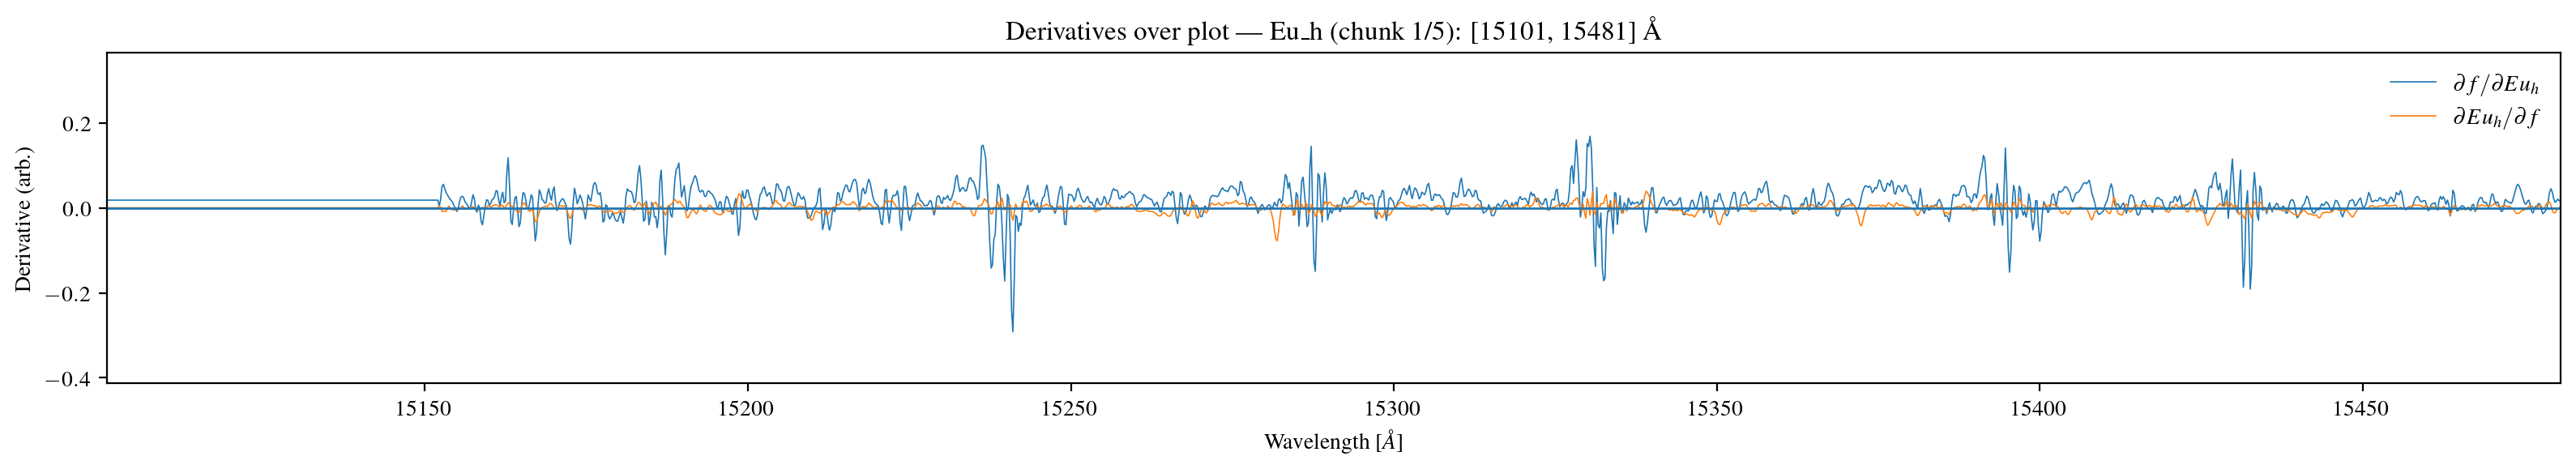

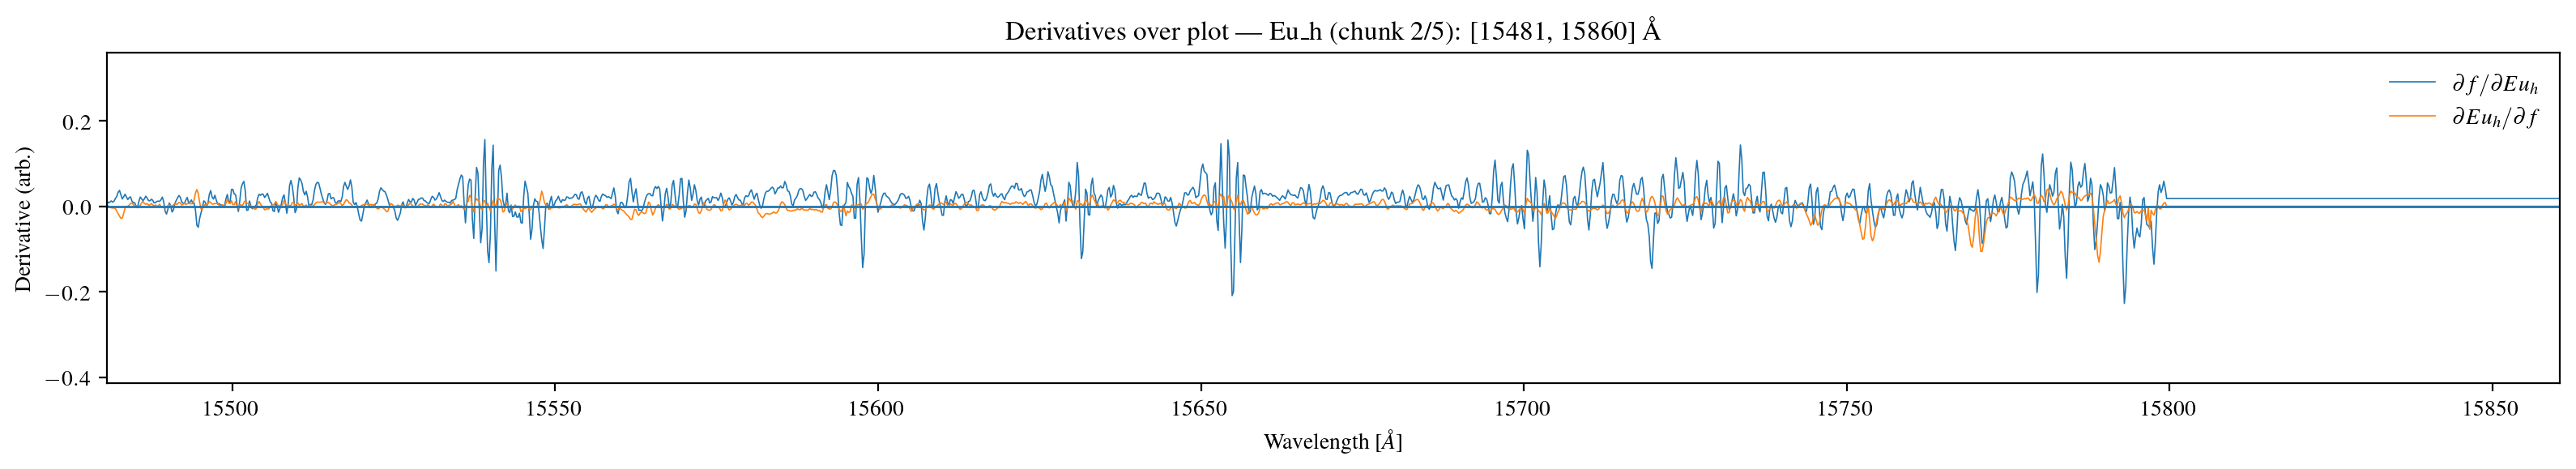

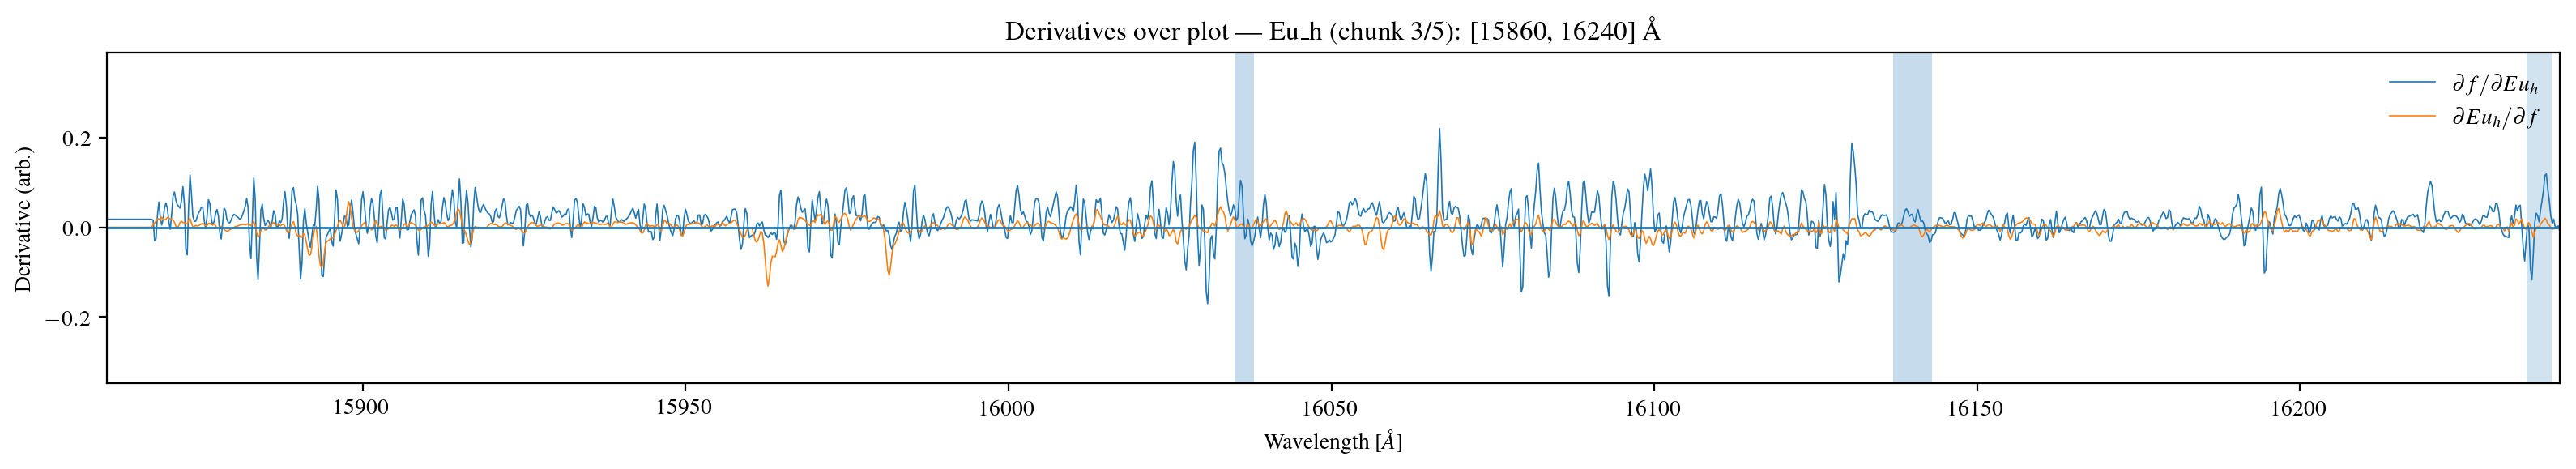

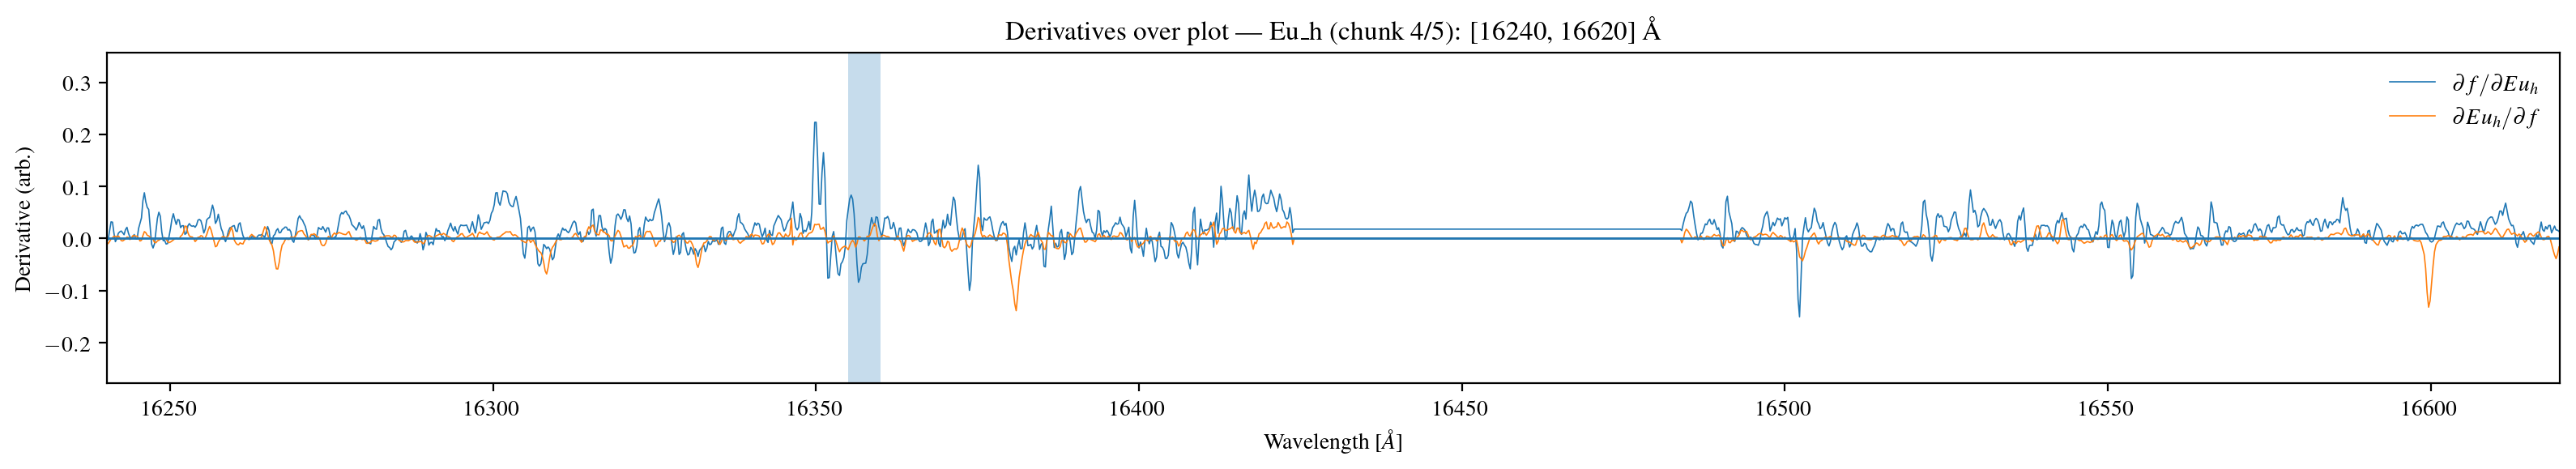

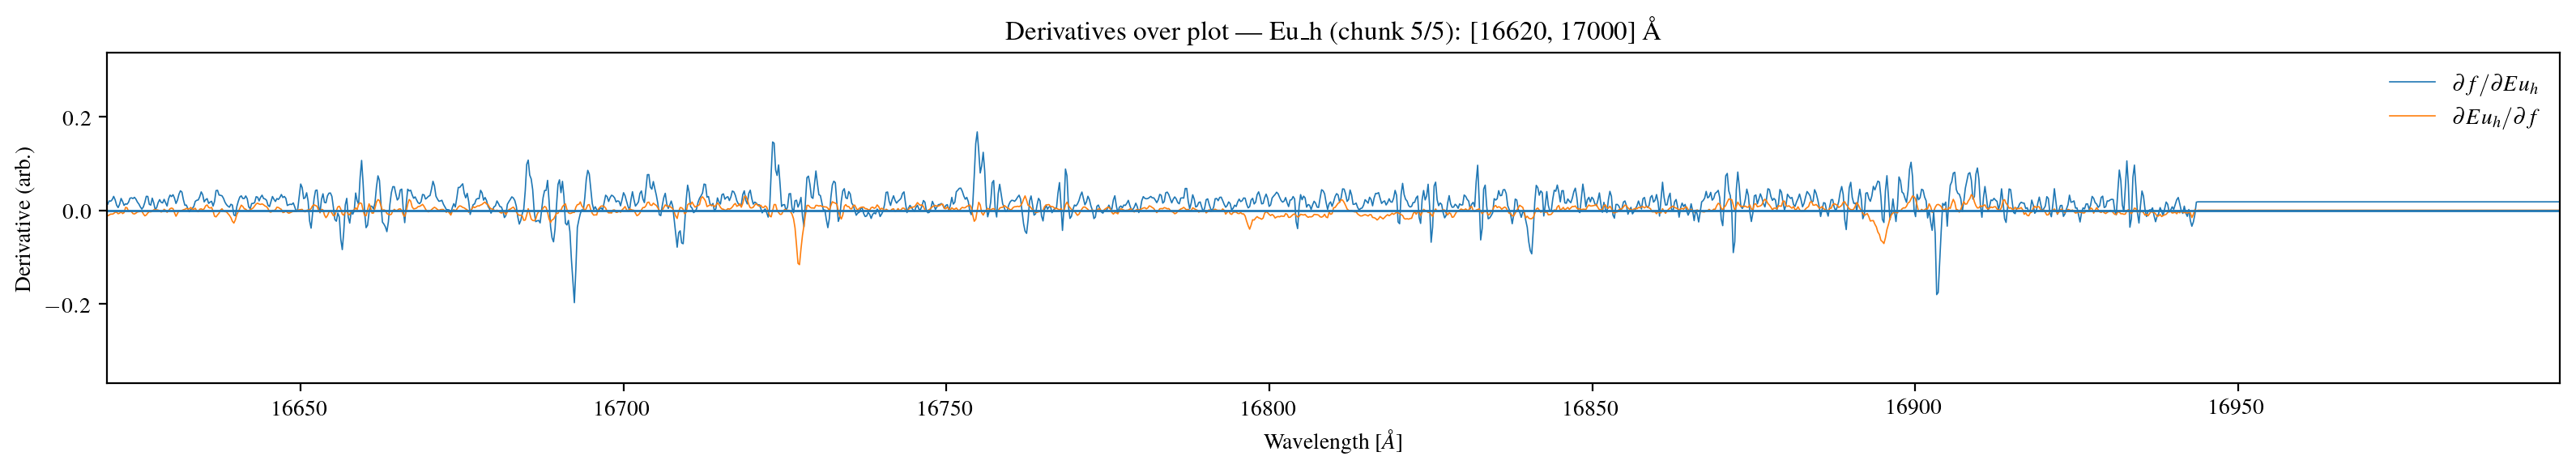

In [ ]:
#A few sp
import os
import numpy as np
import matplotlib.pyplot as plt

#Li regions of interest
regions = REGIONS

# Eu regions of interest
# regions = [
#     (16035, 16038, 0.25),
#     (16137, 16143, 0.25),
#     (16235, 16239, 0.20),
#     (16355, 16360, 0.25)]


outdir_dflux = "/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/Derivatives_plots_Eu_h"
prefix_dflux = "Derivitives_chunk"

label_to_plot = "Eu_h"   # must exist in `names`
vline_x       = None   # set None to disable


os.makedirs(outdir_dflux, exist_ok=True)

w = np.asarray(wavelengths)
FBL = np.asarray(flux_by_labels)   # (n_pix, n_labels)
LBF = np.asarray(labels_by_flux).T

j = names.index(label_to_plot)
d = FBL[:, j]  # dFlux/d(label) as a function of wavelength
y = LBF[:, j]


def nice_ylim(y, p=(0.1, 99.9), pad_frac=0.60):
    lo, hi = np.percentile(y, p)
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad

edges = np.linspace(w.min(), w.max(), 6)

for k in range(5):
    x0, x1 = edges[k], edges[k+1]
    m = (w >= x0) & (w <= x1)

    fig, ax = plt.subplots(figsize=(16, 3), dpi=200)

    if vline_x is not None:
        ax.axvline(vline_x, lw=1)

    # labels for the two curves
    label_d = rf"$\partial f / \partial {label_to_plot}$"      # dFlux/d(label)
    labell  = rf"$\partial {label_to_plot} / \partial f$"      # d(label)/dFlux  (this is the y-line label)

    ax.plot(w[m], d[m], lw=0.6, label=label_d)
    ax.plot(w[m], y[m], lw=0.6, label=labell)
    ax.axhline(0, lw=1)
    for lower, upper, col in regions:
        ax.axvspan(lower, upper, alpha=col)
    ax.set_xlim(x0, x1)
    ax.set_ylim(*nice_ylim(d[m]))

    ax.set_xlabel(r"Wavelength [$\AA$]")
    ax.set_ylabel("Derivative (arb.)")

    # title: "Derivatives over plot"
    ax.set_title(f"Derivatives over plot — {label_to_plot} (chunk {k+1}/5): [{x0:.0f}, {x1:.0f}] Å")

    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()

    # filename: derivatives_plot_<label>_chunkXX_...
    # save_path = os.path.join(
    #     outdir_dflux,
    #     f"derivatives_plot_{label_to_plot}_chunk{k+1:02d}_{x0:.0f}-{x1:.0f}A.png"
    # )

    # fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # print("Saved ->", save_path)

In [ ]:
#This plots a few things, i just differentiate between them by commenting the plots i dont want out
"""
plot_eu_figures.py
==================
Publication-quality figures for Eu doppelganger analysis.

 
Generates:
  Fig 1  — Full spectra overplot  (hero pair)
  Fig 2  — Full derivative plot   (dF/dEu_h  and  dEu_h/dF)
  Fig 3  — Zoomed triptych at 16238 Å  (overplot / difference / derivative)
  Fig 4  — Zoomed triptychs for remaining REGIONS_EU windows
  Fig 5  — All-pairs comparison strip  (overplot + diff for every pair found)
"""
 
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')   # force non-interactive backend so savefig works in Jupyter
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
 
# ── Output ─────────────────────────────────────────────────────────────────────
OUTDIR   = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/PaperFigures_Eu/'
os.makedirs(OUTDIR, exist_ok=True)
 
def savefig(fig, name, dpi=200):
    path = os.path.join(OUTDIR, name + '.png')
    fig.savefig(path, bbox_inches='tight', dpi=dpi)
    print(f'  saved → {path}')
 
# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.labelsize'   : 12,
    'axes.titlesize'   : 11,
    'legend.fontsize'  : 10,
    'xtick.direction'  : 'in',
    'ytick.direction'  : 'in',
    'xtick.top'        : True,
    'ytick.right'      : True,
})
 
COL_MORE   = '#2166ac'   # blue  — more Eu abundant
COL_LESS   = '#d6604d'   # red   — less Eu abundant
COL_DIFF   = '#4d9221'   # green — difference spectrum
COL_DFDEU  = '#2166ac'   # blue  — dF/dEu_h
COL_DEUDF  = '#d6604d'   # red   — dEu_h/dF
ALPHA_HL   = 0.18        # shaded region alpha
 
# ── Regions of interest ────────────────────────────────────────────────────────
# (lower_Å, upper_Å, label)
REGIONS_EU = [
    (16235, 16241, '16238 Å'),   # primary candidate line
]
PRIMARY_REGION = REGIONS_EU[0]
ZOOM_PAD = 15                    # Å either side of region for zoom panels
 
# ── Helper: shade all regions on an axes ──────────────────────────────────────
def shade_regions(ax, regions, primary_idx=2):
    for k, (lo, hi, _) in enumerate(regions):
        colour = '#b2182b' if k == primary_idx else '#4393c3'
        ax.axvspan(lo, hi, alpha=ALPHA_HL, color=colour, lw=0)
 
# ── Helper: nice y limits ──────────────────────────────────────────────────────
def nice_ylim(y, p=(0.5, 99.5), pad=0.30):
    lo, hi = np.percentile(y, p)
    d = pad * (hi - lo)
    return lo - d, hi + d
 
# ══════════════════════════════════════════════════════════════════════════════
# 0.  Assemble variables from notebook scope
# ══════════════════════════════════════════════════════════════════════════════
# These must already exist in the kernel (set by your existing notebook cells).
# Hero pair
HERO_I, HERO_J = 527, 394
 
w   = np.asarray(spectra_data['wl'])           # (n_pix,)
FBL = np.asarray(flux_by_labels)               # (n_pix, n_labels)  dF/d(label)
LBF = np.asarray(labels_by_flux)               # (n_labels, n_pix)  d(label)/dF
 
j_eu = names.index('Eu_h')
 
# Derivative vectors
dF_dEu   = FBL[:, j_eu]          # dFlux / d[Eu/H]  — length n_pix
dEu_dF   = LBF[j_eu, :]          # d[Eu/H] / dFlux  — length n_pix
 
# Hero spectra
more_spec    = np.asarray(spectra_test_fromflux[HERO_I])   # higher [Eu/H]
less_spec    = np.asarray(spectra_test_fromflux[HERO_J])
diff_spec    = more_spec - less_spec
 
more_eu = float(Eu_h[HERO_I])
less_eu = float(Eu_h[HERO_J])
more_label = f'[Eu/H] = {more_eu:+.3f} dex  (star {HERO_I})'
less_label = f'[Eu/H] = {less_eu:+.3f} dex  (star {HERO_J})'
sep_label  = f'Separation: {abs(more_eu - less_eu):.3f} dex'
 
# All pairs (statistical, Eu_h) — computed in your existing notebook cell
# `pairs` must already be populated
all_pairs = pairs   # list of (i,j) tuples
 
# # ══════════════════════════════════════════════════════════════════════════════
# # FIG 1 — Spectra overplot chunks (5 individual PNGs for LaTeX)
# # ══════════════════════════════════════════════════════════════════════════════
# print("Generating Fig 1 — spectra chunks …")
 
# edges = np.linspace(w.min(), w.max(), 6)
# raw_more = np.asarray(test_flux[HERO_I])
# raw_less = np.asarray(test_flux[HERO_J])
 
# for k in range(5):
#     x0, x1 = edges[k], edges[k+1]
#     m_c = (w >= x0) & (w <= x1)
 
#     fig, ax = plt.subplots(figsize=(14, 3.5), dpi=200)
 
#     ax.plot(w[m_c], more_spec[m_c], lw=0.6, color=COL_MORE, zorder=2,
#             label=f'more abundant  [Eu/H] = {more_eu:+.3f} dex')
#     ax.plot(w[m_c], less_spec[m_c], lw=0.6, color=COL_LESS, zorder=2, alpha=0.85,
#             label=f'less abundant   [Eu/H] = {less_eu:+.3f} dex')
#     ax.axvspan(PRIMARY_REGION[0], PRIMARY_REGION[1],
#                alpha=ALPHA_HL*2, color='#b2182b', lw=0)
#     ax.set_xlim(x0, x1)
#     ax.set_ylim(*nice_ylim(np.concatenate([more_spec[m_c], less_spec[m_c]])))
#     ax.set_xlabel(r'Wavelength [$\AA$]', fontsize=20)
#     ax.set_ylabel('Normalised Flux', fontsize=20)
#     ax.set_title(f'Chunk {k+1}/5:  {x0:.0f}-{x1:.0f} A', fontsize=16, pad=3)
#     ax.legend(frameon=False, loc='lower left', fontsize=16)
 
#     fig.tight_layout()
#     savefig(fig, f'fig1_chunk{k+1:02d}_{x0:.0f}-{x1:.0f}A')
#     plt.close(fig)
 
# # ══════════════════════════════════════════════════════════════════════════════
# # FIG 2 — Full derivative plot (5 chunks + combined page)
# # ══════════════════════════════════════════════════════════════════════════════
print('Generating Fig 2 — full derivative plot (5 chunks + combined) …')
 
# Combined figure — 10 rows (2 per chunk: dF/dEu on top, dEu/dF below)
fig_all2, axes_all2 = plt.subplots(10, 1, figsize=(16, 40),
                                    gridspec_kw={'hspace': 0.45})
fig_all2.suptitle('Lux spectral derivatives w.r.t. [Eu/H]', fontsize=13)
 
for k in range(5):
    x0, x1 = edges[k], edges[k+1]
    m_chunk = (w >= x0) & (w <= x1)
 
    def _plot_derivs(ax_top, ax_bot, title=True):
        for ax, deriv, col, lbl, yunits in zip(
                [ax_top, ax_bot],
                [dF_dEu,    dEu_dF],
                [COL_DFDEU, COL_DEUDF],
                [r'$\partial f\,/\,\partial\,[{\rm Eu/H}]$',
                 r'$\partial\,[{\rm Eu/H}]\,/\,\partial f$'],
                ['Flux deriv. (arb.)', 'Abund. deriv. (arb.)']):
            ax.plot(w[m_chunk], deriv[m_chunk], lw=0.6, color=col, label=lbl)
            ax.axhline(0, lw=0.6, color='k', ls='--', alpha=0.4)
            shade_regions(ax, REGIONS_EU)
            ax.set_xlim(x0, x1)
            ax.set_ylim(*nice_ylim(deriv[m_chunk]))
            ax.set_ylabel(yunits, fontsize=16)
            ax.legend(frameon=False, loc='upper right', fontsize=8)
            for rlo, rhi, rlbl2 in REGIONS_EU:
                if rlo >= x0 and rhi <= x1:
                    ax.annotate(rlbl2, xy=((rlo+rhi)/2, ax.get_ylim()[1]),
                                xytext=(0, 4), textcoords='offset points',
                                ha='center', va='bottom', fontsize=8, color='#555555')
        ax_bot.set_xlabel(r'Wavelength [$\AA$]')
        if title:
            ax_top.set_title(
                f'Lux derivatives — chunk {k+1}/5:  {x0:.0f}–{x1:.0f} Å', pad=4)
 
    # dF/dEu — left panel
    fig_a, ax_a = plt.subplots(figsize=(8, 3.5), dpi=200)
    ax_a.plot(w[m_chunk], dF_dEu[m_chunk], lw=0.6, color=COL_DFDEU)
    ax_a.axhline(0, lw=0.6, color='k', ls='--', alpha=0.4)
    shade_regions(ax_a, REGIONS_EU)
    ax_a.set_xlim(x0, x1)
    ax_a.set_ylim(*nice_ylim(dF_dEu[m_chunk]))
    ax_a.set_xlabel(r'Wavelength [$\AA$]', fontsize=16)
    ax_a.set_ylabel(r'$\partial f\,/\,\partial\,[{\rm Eu/H}]$', fontsize=16)
    ax_a.set_title(f'Chunk {k+1}/5:  {x0:.0f}-{x1:.0f} A', fontsize=10, pad=3)
    for rlo, rhi, rlbl2 in REGIONS_EU:
        if rlo >= x0 and rhi <= x1:
            ax_a.annotate(rlbl2, xy=((rlo+rhi)/2, ax_a.get_ylim()[1]),
                          xytext=(0, 4), textcoords='offset points',
                          ha='center', va='bottom', fontsize=8, color='#555555')
    fig_a.tight_layout()
    savefig(fig_a, f'fig2_chunk{k+1:02d}_dF_dEu')
    plt.close(fig_a)
 
    # dEu/dF — right panel
    fig_b, ax_b = plt.subplots(figsize=(8, 3.5), dpi=200)
    ax_b.plot(w[m_chunk], dEu_dF[m_chunk], lw=0.6, color=COL_DEUDF)
    ax_b.axhline(0, lw=0.6, color='k', ls='--', alpha=0.4)
    shade_regions(ax_b, REGIONS_EU)
    ax_b.set_xlim(x0, x1)
    ax_b.set_ylim(*nice_ylim(dEu_dF[m_chunk]))
    ax_b.set_xlabel(r'Wavelength [$\AA$]', fontsize=16)
    ax_b.set_ylabel(r'$\partial\,[{\rm Eu/H}]\,/\,\partial f$', fontsize=16)
    ax_b.set_title(f'Chunk {k+1}/5:  {x0:.0f}-{x1:.0f} A', fontsize=16, pad=3)
    for rlo, rhi, rlbl2 in REGIONS_EU:
        if rlo >= x0 and rhi <= x1:
            ax_b.annotate(rlbl2, xy=((rlo+rhi)/2, ax_b.get_ylim()[1]),
                          xytext=(0, 4), textcoords='offset points',
                          ha='center', va='bottom', fontsize=8, color='#555555')
    fig_b.tight_layout()
    savefig(fig_b, f'fig2_chunk{k+1:02d}_dEu_dF')
    plt.close(fig_b)
 
# # ══════════════════════════════════════════════════════════════════════════════
# # FIG 3 — Primary zoom triptych at 16238 Å
# # ══════════════════════════════════════════════════════════════════════════════
# print('Generating Fig 3 — zoom triptych at 16238 Å …')
 
# lo, hi, rlbl = PRIMARY_REGION
# xlo, xhi = lo - ZOOM_PAD, hi + ZOOM_PAD
# m = (w >= xlo) & (w <= xhi)
 
# fig = plt.figure(figsize=(8, 10))
# gs  = gridspec.GridSpec(3, 1, hspace=0.08, figure=fig)
# ax1 = fig.add_subplot(gs[0])
# ax2 = fig.add_subplot(gs[1], sharex=ax1)
# ax3 = fig.add_subplot(gs[2], sharex=ax1)
 
# # Panel 1 — overplot
# ax1.plot(w[m], more_spec[m], lw=1.0, color=COL_MORE, label=more_label)
# ax1.plot(w[m], less_spec[m], lw=1.0, color=COL_LESS, label=less_label, alpha=0.85)
# ax1.axvspan(lo, hi, alpha=ALPHA_HL*2, color='#b2182b', lw=0)
# ax1.set_ylabel('Normalised Flux', fontsize=16)
# ax1.legend(frameon=False, fontsize=12)

 
# # Panel 2 — difference
# ax2.plot(w[m], diff_spec[m], lw=1.0, color=COL_DIFF)
# ax2.axhline(0, lw=0.7, color='k', ls='--', alpha=0.5)
# ax2.axvspan(lo, hi, alpha=ALPHA_HL*2, color='#b2182b', lw=0)
# ax2.set_ylabel(r'$\Delta$ Flux (more $-$ less)', fontsize=16)
 
# # Panel 3 — derivatives
# ax3.plot(w[m], dF_dEu[m],  lw=1.0, color=COL_DFDEU,
#          label=r'$\partial f\,/\,\partial\,[{\rm Eu/H}]$')
# ax3.plot(w[m], dEu_dF[m],  lw=1.0, color=COL_DEUDF, alpha=0.85,
#          label=r'$\partial\,[{\rm Eu/H}]\,/\,\partial f$')
# ax3.axhline(0, lw=0.7, color='k', ls='--', alpha=0.5)
# ax3.axvspan(lo, hi, alpha=ALPHA_HL*2, color='#b2182b', lw=0)
# ax3.set_ylabel('Derivative (arb.)', fontsize=16)
# ax3.set_xlabel(r'Wavelength [$\AA$]', fontsize=16)
# ax3.legend(frameon=False, fontsize=12)
 
# # Shared formatting
# for ax in [ax1, ax2, ax3]:
#     ax.set_xlim(xlo, xhi)
#     ax.axvline(16238.3, lw=0.8, color='#b2182b', ls=':', alpha=0.6)
 
# # Hide x tick labels on upper panels
# plt.setp(ax1.get_xticklabels(), visible=False)
# plt.setp(ax2.get_xticklabels(), visible=False)
 
# savefig(fig, 'fig3_zoom_16238_triptych')
# plt.close(fig)
 
# ══════════════════════════════════════════════════════════════════════════════
# FIG 4 — Zoomed overplots at 16238 Å for all 3 statistical pairs
#          Uses `pairs` already in scope from find_doppelganger_pairs call above
# ══════════════════════════════════════════════════════════════════════════════
# print('Generating Fig 4 — all pairs zoomed overplots at 16238 Å …')
 
# lo4, hi4, _ = PRIMARY_REGION
# xlo4, xhi4  = lo4 - ZOOM_PAD, hi4 + ZOOM_PAD
# m4 = (w >= xlo4) & (w <= xhi4)
 
# i_eu = names.index('Eu_h')
# custom_pairs = list(pairs)  # copy
# custom_pairs[0] = (261, 536)  # replace pair at index 0

# for pair_idx in range(len(custom_pairs)):
#     pi, pj = custom_pairs[pair_idx]
#     sp_i = np.asarray(spectra_test_fromflux[pi])
#     sp_j = np.asarray(spectra_test_fromflux[pj])
#     eu_i = float(labels[pi, i_eu])
#     eu_j = float(labels[pj, i_eu])
 
#     # ensure sp_more = higher Eu
#     if eu_i < eu_j:
#         pi, pj = pj, pi
#         sp_i, sp_j = sp_j, sp_i
#         eu_i, eu_j = eu_j, eu_i
 
#     fig, ax = plt.subplots(figsize=(10, 3.5), dpi=200)
#     ax.plot(w[m4], sp_i[m4], lw=0.9, color=COL_MORE,
#             label=f'more abundant  [Eu/H] = {eu_i:+.3f} dex  (star {pi})')
#     ax.plot(w[m4], sp_j[m4], lw=0.9, color=COL_LESS, alpha=0.85,
#             label=f'less abundant   [Eu/H] = {eu_j:+.3f} dex  (star {pj})')
#     ax.axvspan(lo4, hi4, alpha=ALPHA_HL*2, color='#b2182b', lw=0)
#     ax.axvline(16238.5, lw=0.8, color='#b2182b', ls=':', alpha=0.6)
#     ax.set_xlim(xlo4, xhi4)
#     ax.set_ylim(*nice_ylim(np.concatenate([sp_i[m4], sp_j[m4]])))
#     ax.set_xlabel(r'Wavelength [$\AA$]', fontsize=16)
#     ax.set_ylabel('Normalised Flux', fontsize=16)
#     ax.set_title(f'Statistical pair {pair_idx+1}  —  $\\Delta$[Eu/H] = {abs(eu_i-eu_j):.3f} dex')
#     ax.legend(frameon=False, fontsize=12, loc='upper right')
#     fig.tight_layout()
#     savefig(fig, f'fig4_pair{pair_idx+1:02d}_zoom_16238')
#     plt.close(fig)
 
 
print('\nAll figures saved to:', OUTDIR)

Generating Fig 2 — full derivative plot (5 chunks + combined) …
  saved → /home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/PaperFigures_Eu/fig2_chunk01_dF_dEu.png
  saved → /home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/PaperFigures_Eu/fig2_chunk01_dEu_dF.png
  saved → /home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/PaperFigures_Eu/fig2_chunk02_dF_dEu.png
  saved → /home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/PaperFigures_Eu/fig2_chunk02_dEu_dF.png
  saved → /home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/PaperFigures_Eu/fig2_chunk03_dF_dEu.png
  saved → /home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/PaperFigures_Eu/fig2_chunk03_dEu_dF.png
  saved → /home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/PaperFigures_Eu/fig2_chunk04_dF_dEu.png
  saved → /home/finrenton/Documents/University/YR4Sem2/SeniorHonours

/tmp/ipykernel_2561094/3555732417.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


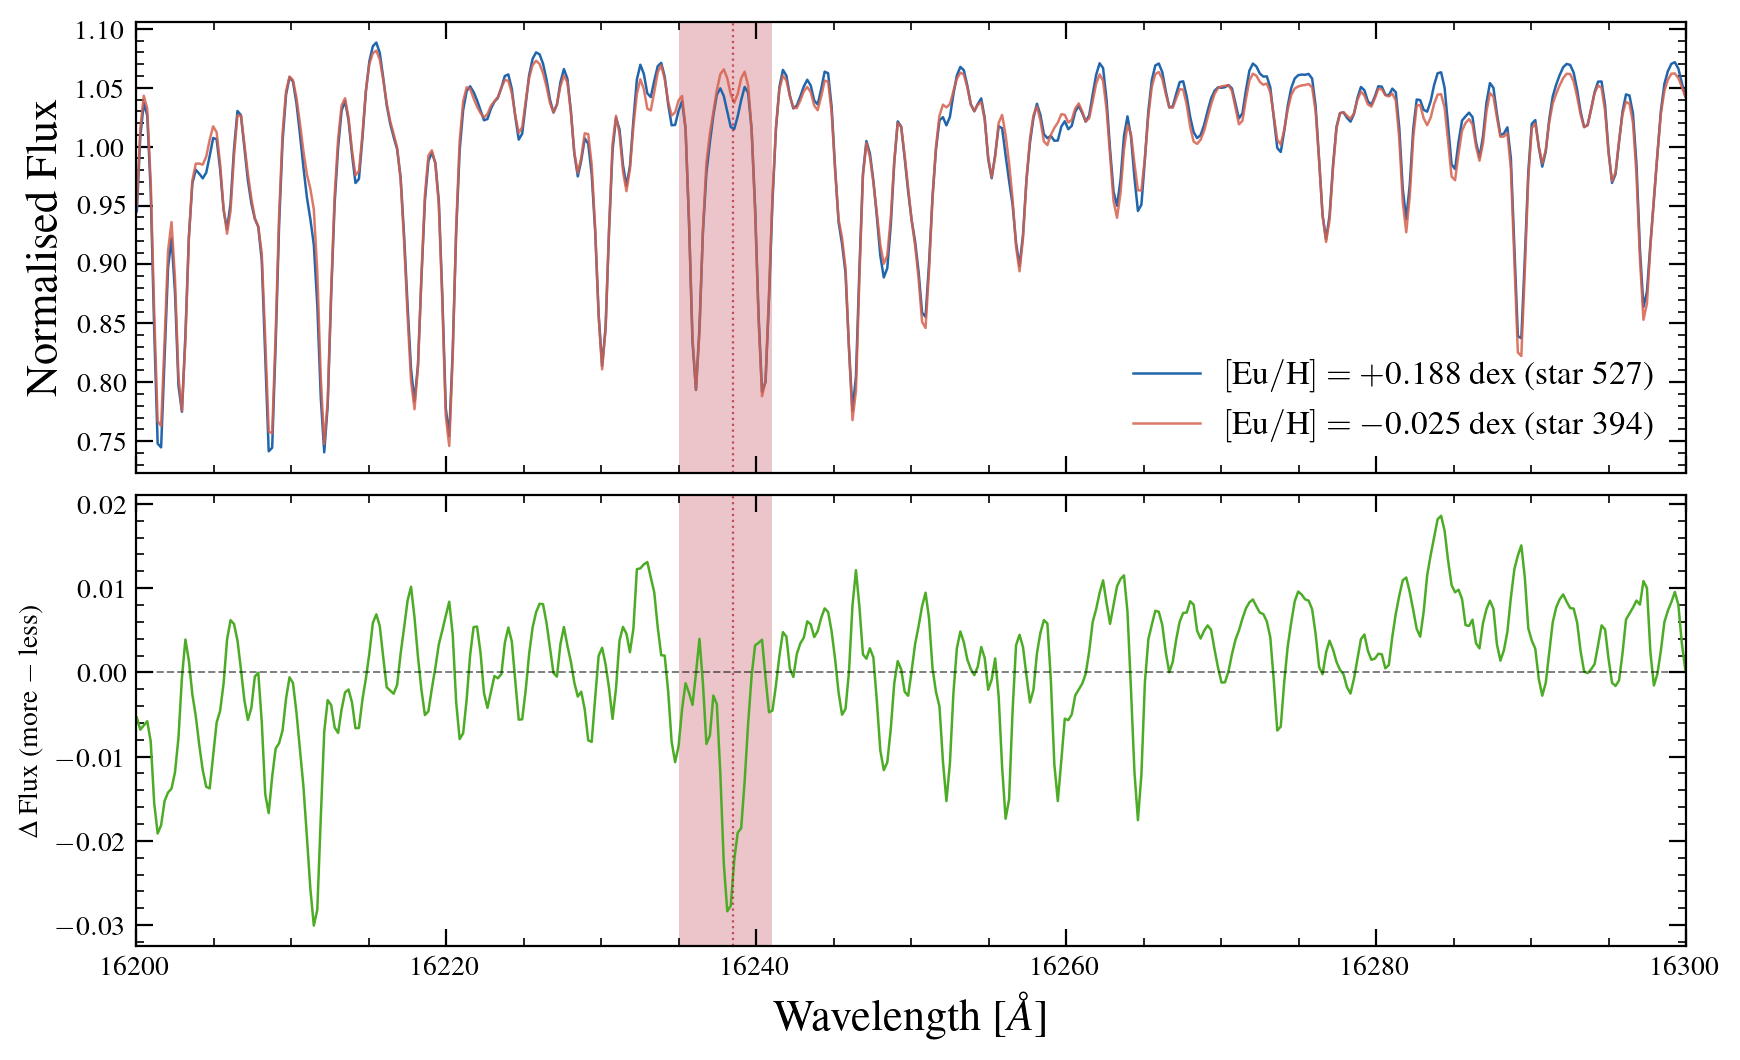

In [ ]:
#Pannel lallowing plotting of a shorter wavelength with overplots and derivatives

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Times']})
rc('text', usetex=True)

# ── region settings ──────────────────────────────────────────────────────────
XLO, XHI     = 16200, 16300          # wavelength window
HL_LO, HL_HI = 16235, 16241          # highlighted candidate region
CANDIDATE    = 16238.5   # centre line

COL_MORE = '#2166ac'   # blue  — more Eu
COL_LESS = '#d6604d'   # red   — less Eu
COL_DIFF = '#4dac26'   # green — difference

# # ── pick pair ────────────────────────────────────────────────────────────────
# # use pair index 2 (statistical pair 3, highest separation = 0.322 dex)
pair_idx = 1
pi, pj   = pairs[pair_idx]

# pi, pj = int(i), int(j)  # from your vectorised max-separation search

w  = np.asarray(wavelengths)
i_eu   = names.index('Eu_h')
sp_i   = np.asarray(spectra_test_fromflux[pi])
sp_j   = np.asarray(spectra_test_fromflux[pj])
eu_i   = float(labels[pi, i_eu])
eu_j   = float(labels[pj, i_eu])

# ensure sp_more = higher Eu
if eu_i < eu_j:
    pi, pj   = pj, pi
    sp_i, sp_j = sp_j, sp_i
    eu_i, eu_j = eu_j, eu_i

more_label = f'$[{{\\rm Eu/H}}] = {eu_i:+.3f}$ dex  (star {pi})'
less_label = f'$[{{\\rm Eu/H}}] = {eu_j:+.3f}$ dex  (star {pj})'
diff_spec  = sp_i - sp_j

# ── wavelength mask ───────────────────────────────────────────────────────────
m = (w >= XLO) & (w <= XHI)

# ── figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 6), dpi=200)
gs  = gridspec.GridSpec(2, 1, hspace=0.05, figure=fig)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# Panel 1 — overplot
ax1.plot(w[m], sp_i[m], lw=0.9, color=COL_MORE, label=more_label)
ax1.plot(w[m], sp_j[m], lw=0.9, color=COL_LESS, label=less_label, alpha=0.85)
ax1.axvspan(HL_LO, HL_HI, alpha=0.25, color='#b2182b', lw=0)
ax1.axvline(CANDIDATE, lw=0.8, color='#b2182b', ls=':', alpha=0.7)
ax1.set_ylabel('Normalised Flux', fontsize=16)
ax1.legend(frameon=False, fontsize=12, loc='lower right')
ax1.set_xlim(XLO, XHI)
plt.setp(ax1.get_xticklabels(), visible=False)
ax1.tick_params(which='major', direction='in', top=True, right=True, length=6)
ax1.tick_params(which='minor', direction='in', top=True, right=True, length=3)
ax1.minorticks_on()

# Panel 2 — difference
ax2.plot(w[m], diff_spec[m], lw=0.9, color=COL_DIFF)
ax2.axhline(0, lw=0.7, color='k', ls='--', alpha=0.5)
ax2.axvspan(HL_LO, HL_HI, alpha=0.25, color='#b2182b', lw=0)
ax2.axvline(CANDIDATE, lw=0.8, color='#b2182b', ls=':', alpha=0.7)
ax2.set_ylabel(r'$\Delta$ Flux (more $-$ less)', fontsize=10)
ax2.set_xlabel(r'Wavelength [$\AA$]', fontsize=16)
ax2.set_xlim(XLO, XHI)
ax2.tick_params(which='major', direction='in', top=True, right=True, length=6)
ax2.tick_params(which='minor', direction='in', top=True, right=True, length=3)
ax2.minorticks_on()

fig.tight_layout()
plt.savefig('/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/fig_zoom_16000_16300_overplot_diff.pdf',
            dpi=200, bbox_inches='tight')
plt.show()

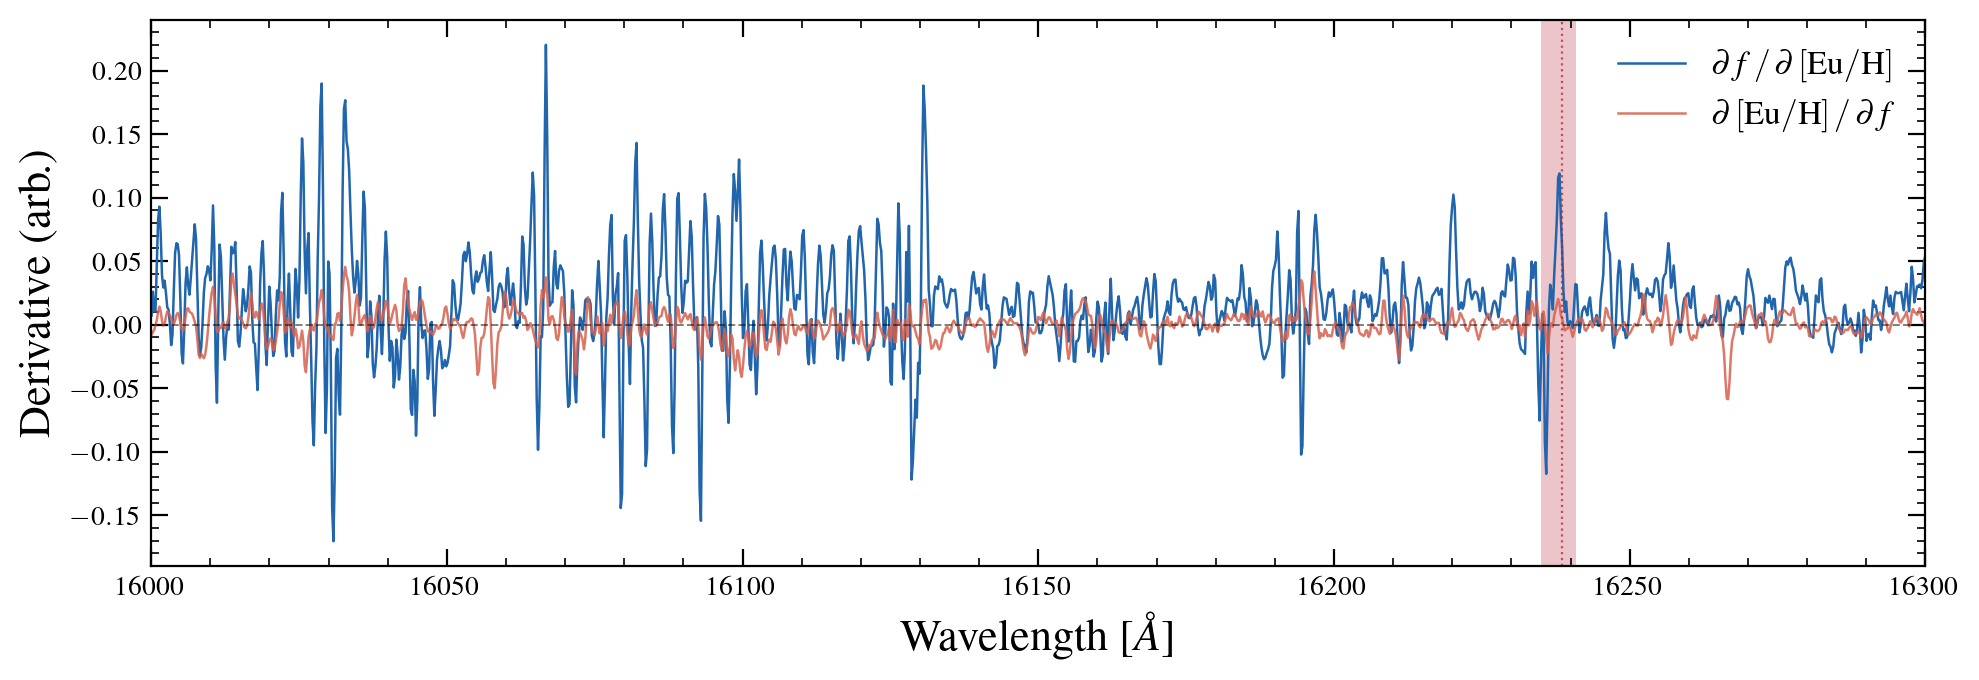

In [ ]:
#Same as above but for derivatives

w   = np.asarray(spectra_data['wl'])           # (n_pix,)
FBL = np.asarray(flux_by_labels)               # (n_pix, n_labels)  dF/d(label)
LBF = np.asarray(labels_by_flux)               # (n_labels, n_pix)  d(label)/dF
 
j_eu = names.index('Eu_h')
 
# Derivative vectors
dF_dEu   = FBL[:, j_eu]          # dFlux / d[Eu/H]  — length n_pix
dEu_dF   = LBF[j_eu, :]  

COL_DFDEU = '#2166ac'  # blue
COL_DEUDF = '#d6604d'  # red

fig, ax = plt.subplots(figsize=(10, 3.5), dpi=200)

m = (w >= 16000) & (w <= 16300)

ax.plot(w[m], dF_dEu[m],  lw=0.9, color=COL_DFDEU,
        label=r'$\partial f\,/\,\partial\,[{\rm Eu/H}]$')
ax.plot(w[m], dEu_dF[m],  lw=0.9, color=COL_DEUDF, alpha=0.85,
        label=r'$\partial\,[{\rm Eu/H}]\,/\,\partial f$')
ax.axhline(0, lw=0.7, color='k', ls='--', alpha=0.5)
ax.axvspan(16235, 16241, alpha=0.25, color='#b2182b', lw=0)
ax.axvline(16238.5, lw=0.8, color='#b2182b', ls=':', alpha=0.7)
ax.set_xlabel(r'Wavelength [$\AA$]', fontsize=16)
ax.set_ylabel(r'Derivative (arb.)', fontsize=16)
ax.set_xlim(16000, 16300)
ax.legend(frameon=False, fontsize=12, loc='upper right')
ax.tick_params(which='major', direction='in', top=True, right=True, length=6)
ax.tick_params(which='minor', direction='in', top=True, right=True, length=3)
ax.minorticks_on()

fig.tight_layout()
plt.savefig('/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/fig_derivative_16000_16300.pdf',
            dpi=200, bbox_inches='tight')
plt.show()
plt.show()